In [1]:
import warnings
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Concatenate, Flatten, Embedding, Reshape, ReLU
from tensorflow.keras.preprocessing import image
import keras.backend as K
from tqdm.notebook import tqdm
from tabulate import tabulate
from IPython.display import clear_output, display, Image as IPImage
import ipywidgets as widgets
from scipy import linalg
from skimage.metrics import structural_similarity as ssim
import pandas as pd
from sklearn.utils import check_random_state
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import glob
import imageio
import time
import random


# Suppress all warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

%matplotlib inline

2026-04-08 11:57:19.979104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775649440.365195      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775649440.477957      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775649441.782682      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775649441.782745      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775649441.782748      55 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 9999

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

np.random.seed(SEED)
random.seed(SEED)

pd.set_option('compute.use_numba', False)

print("All seeds set to", SEED)
print("op_determinism enabled")
print("TensorFlow reproducibility setup complete")

All seeds set to 9999
op_determinism enabled
TensorFlow reproducibility setup complete


In [3]:
IMG_SIZE=28
BATCH_SIZE=64
EPOCHS=200
LATENT_DIM=100
NUM_COLOR_CHANNEL=1
IMG_FLAT=IMG_SIZE*IMG_SIZE*NUM_COLOR_CHANNEL
LR_G=0.0005
LR_D=0.0002
BUFFER_SIZE=10000
N_CLASS = 10
DATA_ROOT="/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv"
df=pd.read_csv(DATA_ROOT)

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Build Generator

In [5]:
def build_generator(noise_dim=LATENT_DIM, n_class=N_CLASS):
    in_lat = Input(shape=(noise_dim,))
    z = Dense(200)(in_lat)
    z = ReLU()(z)
    in_label = Input(shape=(1,))
    y = tf.keras.layers.Embedding(n_class, 50)(in_label)
    y = Dense(1000)(y)
    y = ReLU()(y)
    y = tf.keras.layers.Flatten()(y)
    merge = Concatenate()([z, y])
    gen = Dense(1200)(merge)
    gen = ReLU()(gen)
    gen = Dense(IMG_FLAT, activation='sigmoid')(gen)
    out_layer = Reshape((IMG_SIZE, IMG_SIZE, NUM_COLOR_CHANNEL))(gen)
    model = Model([in_lat, in_label], out_layer)
    return model
g_model = build_generator()
g_model.summary()

I0000 00:00:1775649482.088513      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        500 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1000)   │     51,000 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 200)       │     20,200 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1000)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 200)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1000)      │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1200)      │          0 │ re_lu[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1200)      │  1,441,200 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 1200)      │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 784)       │    941,584 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,454,484 (9.36 MB)

 Trainable params: 2,454,484 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

# Build Discriminator

In [6]:
def build_discriminator():
    in_image = Input(shape=(IMG_SIZE, IMG_SIZE, NUM_COLOR_CHANNEL))
    in_label = Input(shape=(1,))

    li = Embedding(N_CLASS, 50)(in_label)
    li = Dense(IMG_SIZE * IMG_SIZE)(li)
    li = Reshape((IMG_SIZE, IMG_SIZE, NUM_COLOR_CHANNEL))(li)

    merge = Concatenate()([in_image, li])
    flat = Flatten()(merge)

    d = Dense(1024)(flat)
    d = LeakyReLU(alpha=0.2)(d)

    d = Dense(512)(d)
    d = LeakyReLU(alpha=0.2)(d)

    d = Dense(256)(d)
    d = LeakyReLU(alpha=0.2)(d)

    out_layer = Dense(1, activation='sigmoid')(d)

    model = Model([in_image, in_label], out_layer)
    return model

d_model = build_discriminator()
d_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        500 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 784)    │     39,984 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1568)      │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1024)      │  1,606,656 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 1024)      │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │    524,800 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 512)       │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    131,328 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 256)       │          0 │ dense_7[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        257 │ leaky_re_lu_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,303,525 (8.79 MB)

 Trainable params: 2,303,525 (8.79 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
y_train = df['label'].values.astype('int32')
x_train = df.drop('label', axis=1).values.astype('float32')

# Normalize and reshape
x_train = x_train / 255.0
x_train = x_train.reshape(-1, IMG_SIZE, IMG_SIZE, NUM_COLOR_CHANNEL)

def create_cgan_dataset(images, labels, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.shuffle(buffer_size=BUFFER_SIZE)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_dataset = create_cgan_dataset(x_train, y_train, BATCH_SIZE)

In [8]:
for img_batch, label_batch in train_dataset.take(1):
    print(f"Real Image Batch Shape: {img_batch.shape}")   # Should be (64, 784)
    print(f"Real Label Batch Shape: {label_batch.shape}")  # Should be (64,)
    
    # Check if pixels are actually normalized
    print(f"Pixel Range: {img_batch.numpy().min()} to {img_batch.numpy().max()}")

Real Image Batch Shape: (64, 28, 28, 1)
Real Label Batch Shape: (64,)
Pixel Range: 0.0 to 1.0


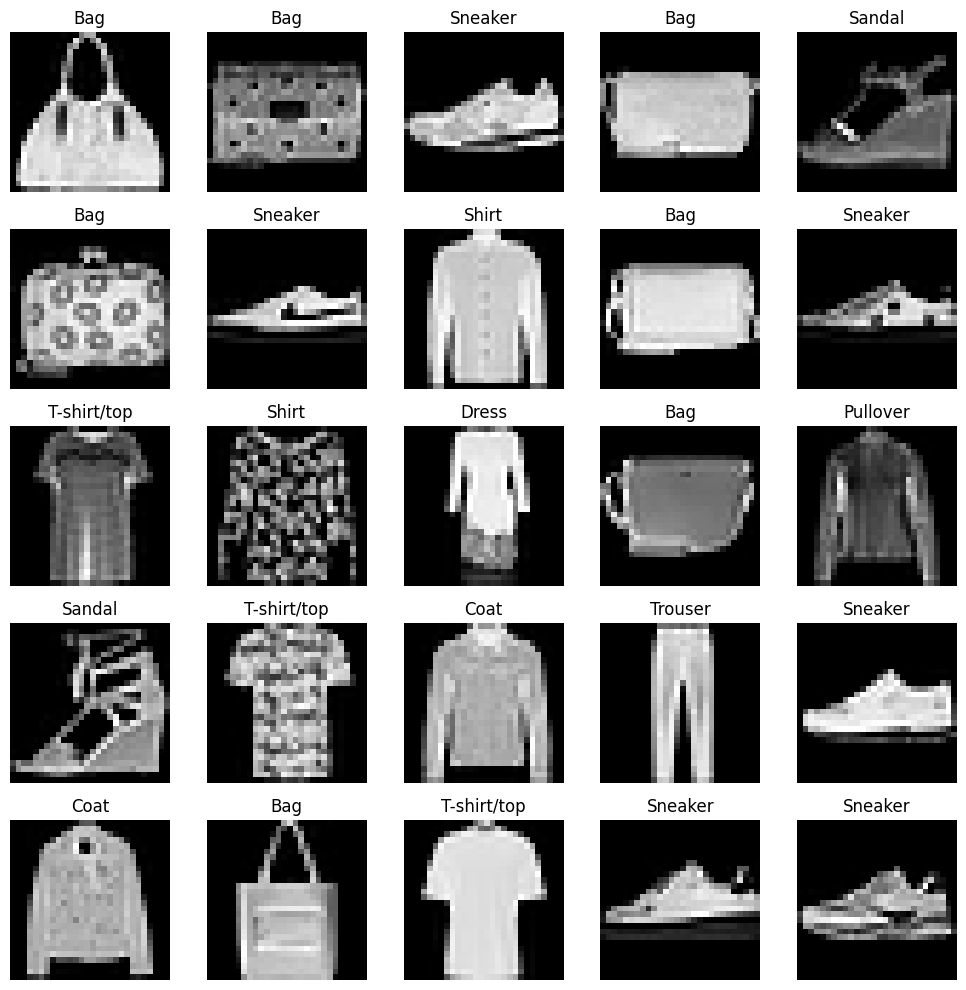

In [9]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        
        img = images[i].numpy().reshape(28, 28)
        label_idx = labels[i].numpy()
        
        plt.imshow(img, cmap='gray')
        plt.title(f"{class_names[label_idx]}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    break

In [10]:
d_optimizer = tf.keras.optimizers.Adam(learning_rate=LR_D, beta_1=0.5)
g_optimizer = tf.keras.optimizers.Adam(learning_rate=LR_G, beta_1=0.5)
cross_entropy = tf.keras.losses.BinaryCrossentropy()

fixed_noise = tf.random.normal([25, LATENT_DIM])
fixed_labels = tf.constant(np.tile(np.arange(N_CLASS), 3)[:25], dtype=tf.int32)

In [11]:
@tf.function
def train_step(real_images, real_labels):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as d_tape:
        real_output = d_model([real_images, real_labels], training=True)
        fake_images = g_model([noise, real_labels], training=True)
        fake_output = d_model([fake_images, real_labels], training=True)
        d_loss_real = cross_entropy(tf.ones_like(real_output), real_output)
        d_loss_fake = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss = d_loss_real + d_loss_fake

    d_grads = d_tape.gradient(d_loss, d_model.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grads, d_model.trainable_variables))

    with tf.GradientTape() as g_tape:
        fake_images = g_model([noise, real_labels], training=True)
        fake_output = d_model([fake_images, real_labels], training=True)
        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    g_grads = g_tape.gradient(g_loss, g_model.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, g_model.trainable_variables))

    d_real_acc = tf.reduce_mean(tf.cast(real_output > 0.5, tf.float32))
    d_fake_acc = tf.reduce_mean(tf.cast(fake_output < 0.5, tf.float32))
    g_acc = tf.reduce_mean(tf.cast(fake_output > 0.5, tf.float32))

    return d_loss, g_loss, d_real_acc, d_fake_acc, g_acc

In [12]:
img_output = widgets.Output()

def generate_and_save_images(generator, epoch):
    predictions = generator([fixed_noise, fixed_labels], training=False)
    fig = plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')
        plt.title(f"Class {fixed_labels[i].numpy()}", fontsize=10)
    plt.suptitle(f'cGAN Generated Samples - Epoch {epoch + 1}', fontsize=16)
    plt.tight_layout()
    with img_output:
        clear_output(wait=True)
        plt.show()
    plt.close(fig)

display(img_output)

print("Starting Professional cGAN Training...\n")
epoch_data = []
pbar = tqdm(
    range(EPOCHS),
    desc=" cGAN Training",
    ncols=120,
    colour="#00ff88",
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]",
    dynamic_ncols=True,
    smoothing=0.1
)

for epoch in pbar:
    d_losses, g_losses = [], []
    d_real_accs, d_fake_accs, g_accs = [], [], []

    for real_images, real_labels in train_dataset:
        d_loss, g_loss, d_real_acc, d_fake_acc, g_acc = train_step(real_images, real_labels)
        d_losses.append(d_loss.numpy())
        g_losses.append(g_loss.numpy())
        d_real_accs.append(d_real_acc.numpy())
        d_fake_accs.append(d_fake_acc.numpy())
        g_accs.append(g_acc.numpy())

    avg_d_loss = np.mean(d_losses)
    avg_g_loss = np.mean(g_losses)
    avg_d_real_acc = np.mean(d_real_accs)
    avg_d_fake_acc = np.mean(d_fake_accs)
    avg_g_acc = np.mean(g_accs)

    pbar.set_postfix({
        'D_loss': f'{avg_d_loss:.4f}',
        'G_loss': f'{avg_g_loss:.4f}',
        'D_real': f'{avg_d_real_acc:.3f}',
        'D_fake': f'{avg_d_fake_acc:.3f}',
        'G_acc': f'{avg_g_acc:.3f}'
    })

    epoch_data.append([
        epoch + 1,
        f"{avg_d_loss:.4f}",
        f"{avg_g_loss:.4f}",
        f"{avg_d_real_acc:.3f}",
        f"{avg_d_fake_acc:.3f}",
        f"{avg_g_acc:.3f}"
    ])

    if (epoch + 1) % 5 == 0 and (epoch + 1) != EPOCHS:
        table = tabulate(
            epoch_data[-5:],
            headers=["Epoch", "Disc Loss", "Gen Loss", "Disc Real Acc (↑)", "Disc Fake Acc (↑)", "Gen Fool Rate (↑)"],
            tablefmt="grid"
        )
        tqdm.write(f"\nLast 5 Epochs Summary:\n{table}\n")

    tqdm.write(f"[Epoch {epoch + 1}/{EPOCHS}] Generating samples...")
    generate_and_save_images(g_model, epoch)

print("\n=== Training Completed Successfully ===\n")
final_table = tabulate(epoch_data,headers=["Epoch", "Disc Loss", "Gen Loss", "Disc Real Acc (↑)", "Disc Fake Acc (↑)", "Gen Fool Rate (↑)"],tablefmt="grid")
print(final_table)

Output()

Starting Professional cGAN Training...



 cGAN Training:   0%|          | 0/200 [00:00<?, ?it/s]

[Epoch 1/200] Generating samples...
[Epoch 2/200] Generating samples...
[Epoch 3/200] Generating samples...
[Epoch 4/200] Generating samples...

Last 5 Epochs Summary:
+---------+-------------+------------+---------------------+---------------------+---------------------+
|   Epoch |   Disc Loss |   Gen Loss |   Disc Real Acc (↑) |   Disc Fake Acc (↑) |   Gen Fool Rate (↑) |
+=========+=============+============+=====================+=====================+=====================+
|       1 |      0.8579 |     2.5072 |               0.775 |               0.98  |               0.02  |
+---------+-------------+------------+---------------------+---------------------+---------------------+
|       2 |      1.0345 |     1.6266 |               0.694 |               0.944 |               0.056 |
+---------+-------------+------------+---------------------+---------------------+---------------------+
|       3 |      1.0956 |     1.4406 |               0.675 |               0.937 |               

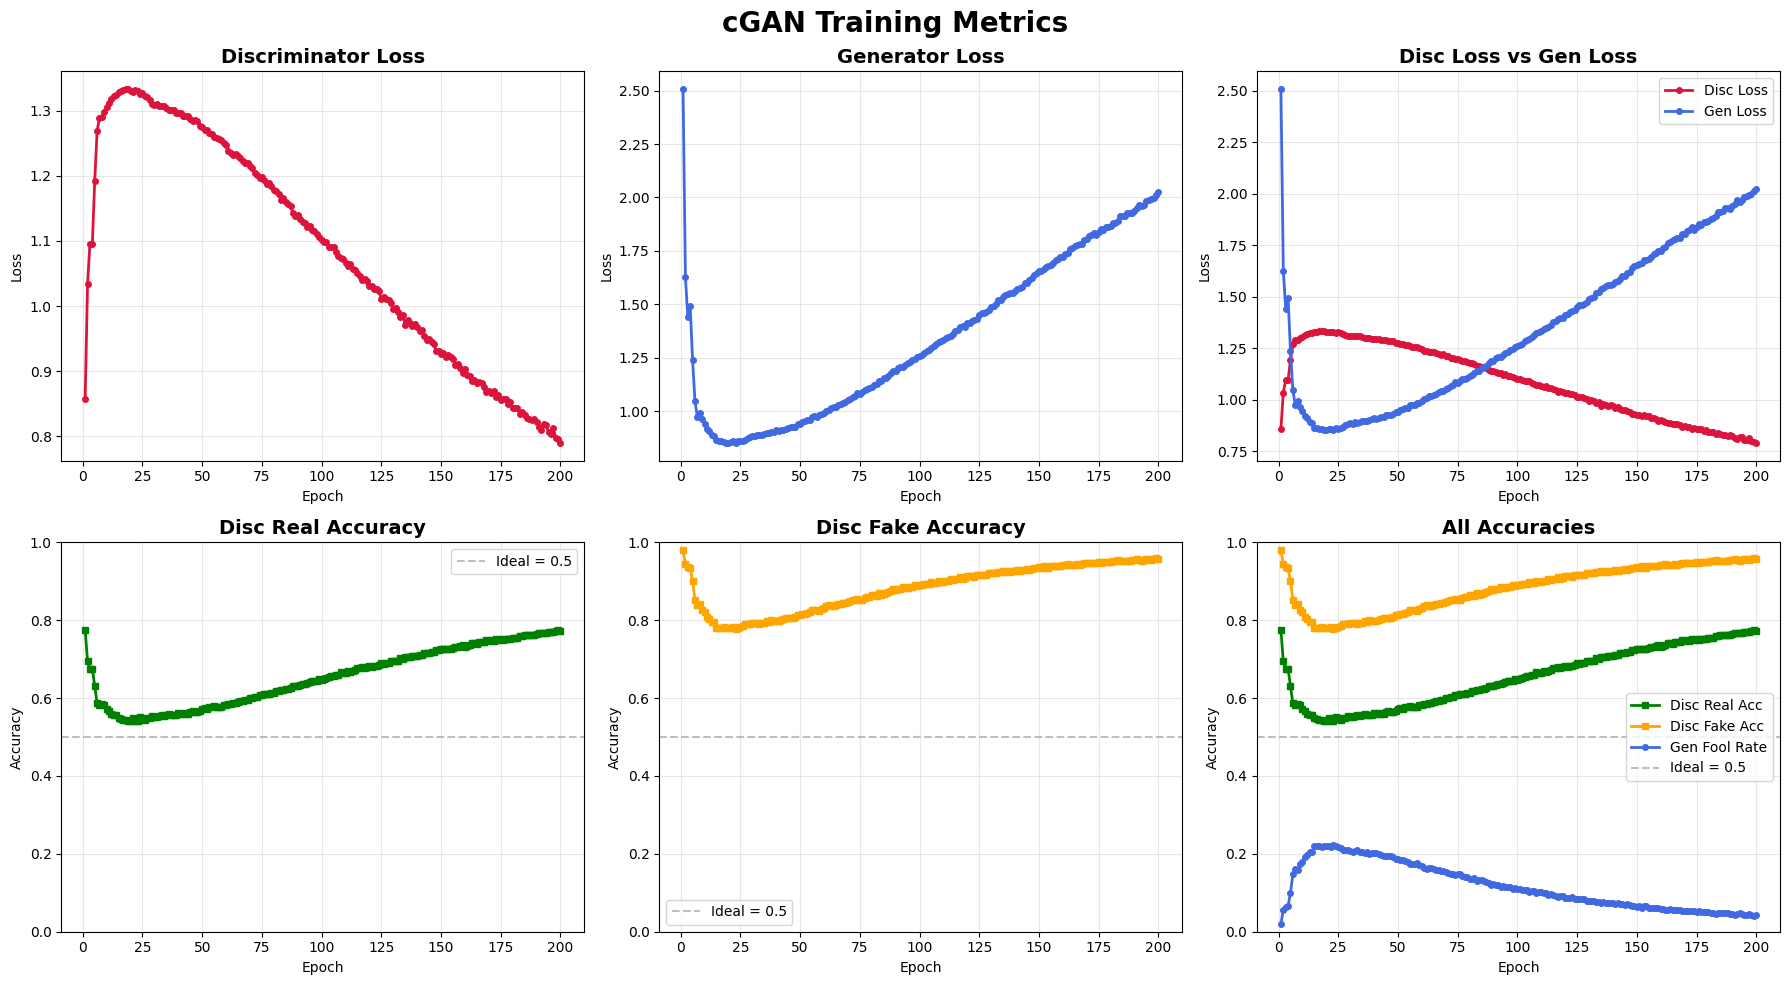

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('cGAN Training Metrics', fontsize=20, fontweight='bold')

epochs_range = [row[0] for row in epoch_data]
d_losses     = [float(row[1]) for row in epoch_data]
g_losses     = [float(row[2]) for row in epoch_data]
d_real_accs  = [float(row[3]) for row in epoch_data]
d_fake_accs  = [float(row[4]) for row in epoch_data]
g_accs       = [float(row[5]) for row in epoch_data]

axes[0, 0].plot(epochs_range, d_losses, color='crimson', linewidth=2, marker='o', markersize=4)
axes[0, 0].set_title('Discriminator Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, g_losses, color='royalblue', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_title('Generator Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(epochs_range, d_losses, color='crimson', linewidth=2, marker='o', markersize=4, label='Disc Loss')
axes[0, 2].plot(epochs_range, g_losses, color='royalblue', linewidth=2, marker='o', markersize=4, label='Gen Loss')
axes[0, 2].set_title('Disc Loss vs Gen Loss', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, d_real_accs, color='green', linewidth=2, marker='s', markersize=4)
axes[1, 0].set_title('Disc Real Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Ideal = 0.5')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_range, d_fake_accs, color='orange', linewidth=2, marker='s', markersize=4)
axes[1, 1].set_title('Disc Fake Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Ideal = 0.5')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(epochs_range, d_real_accs, color='green', linewidth=2, marker='s', markersize=4, label='Disc Real Acc')
axes[1, 2].plot(epochs_range, d_fake_accs, color='orange', linewidth=2, marker='s', markersize=4, label='Disc Fake Acc')
axes[1, 2].plot(epochs_range, g_accs, color='royalblue', linewidth=2, marker='o', markersize=4, label='Gen Fool Rate')
axes[1, 2].set_title('All Accuracies', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Accuracy')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Ideal = 0.5')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

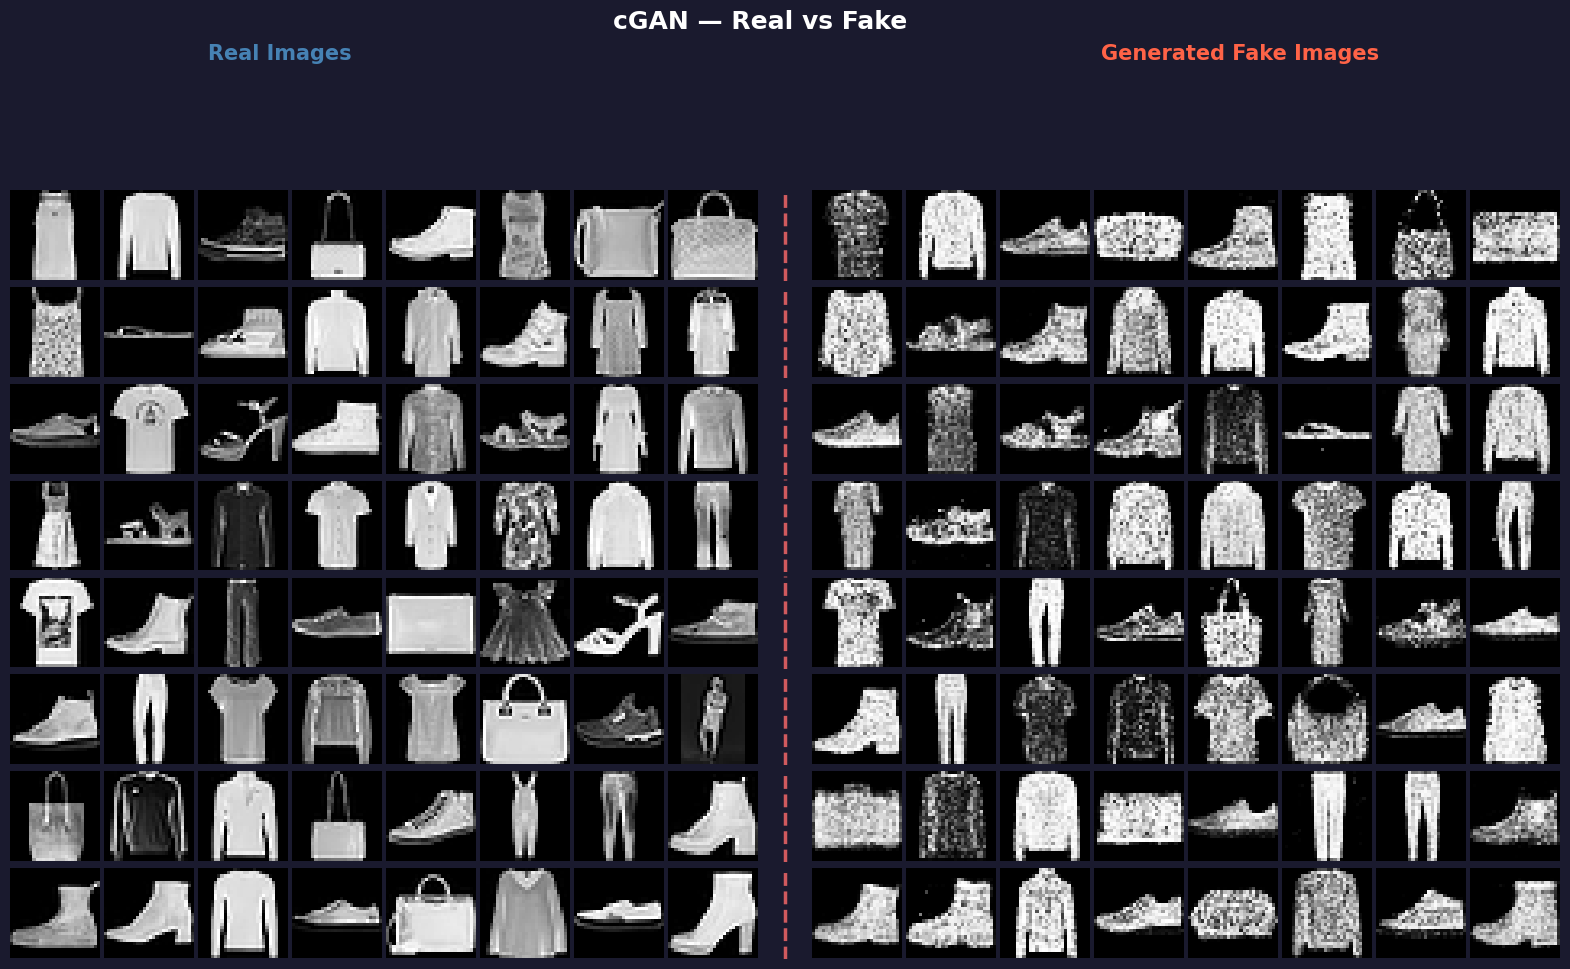

In [14]:
real_batch_images, real_batch_labels = next(iter(train_dataset))
real_batch_images = real_batch_images[:64]
real_batch_labels = real_batch_labels[:64]

noise = tf.random.normal([64, LATENT_DIM])
fake_images = g_model([noise, real_batch_labels], training=False).numpy()
real_images_np = real_batch_images.numpy()

fig = plt.figure(figsize=(20, 10), facecolor='#1a1a2e')
gs = fig.add_gridspec(8, 17, wspace=0.05, hspace=0.05,width_ratios=[1]*8 + [0.5] + [1]*8)

for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        ax = fig.add_subplot(gs[row, col])
        img = np.clip((real_images_np[idx, :, :, 0] + 1) / 2.0, 0, 1)
        ax.imshow(img, cmap='gray')
        ax.axis('off')

for row in range(8):
    ax = fig.add_subplot(gs[row, 8])
    ax.set_facecolor('#1a1a2e')
    ax.axvline(x=0.5, color='#ff6b6b', linewidth=2.5, linestyle='--', alpha=0.8)
    ax.axis('off')

for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        ax = fig.add_subplot(gs[row, col + 9])
        img = np.clip((fake_images[idx, :, :, 0] + 1) / 2.0, 0, 1)
        ax.imshow(img, cmap='gray')
        ax.axis('off')

fig.text(0.26, 1.01, 'Real Images', ha='center', fontsize=15,fontweight='bold', color='steelblue')
fig.text(0.74, 1.01, 'Generated Fake Images', ha='center', fontsize=15,fontweight='bold', color='tomato')
fig.suptitle('cGAN — Real vs Fake', fontsize=18,fontweight='bold', color='white', y=1.06)

plt.savefig('real_vs_fake.png', dpi=150, bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()

In [15]:
print("Computing GAN Metrics...\n")

METRIC_COL = 50
VALUE_COL  = 12

# ── Helper: denormalize [-1,1] → [0,1] ───────────────────────────────────────
def denorm(images):
    return np.clip((images + 1) / 2.0, 0, 1)

# ── Grab real & generate fake images ─────────────────────────────────────────
real_batch, real_labels = next(iter(train_dataset))
real_np  = denorm(real_batch.numpy())
noise    = tf.random.normal([len(real_np), LATENT_DIM])
fake_gen = g_model([noise, real_labels], training=False)
fake_np  = denorm(fake_gen.numpy())

# ═══════════════════════════════════════════════════════════════════════════════
# 1. DISCRIMINATOR ACCURACY METRICS
# ═══════════════════════════════════════════════════════════════════════════════
real_out = d_model([real_batch, real_labels], training=False).numpy().flatten()
fake_out = d_model([fake_gen, real_labels],   training=False).numpy().flatten()

d_real_acc  = np.mean(real_out > 0.5)
d_fake_acc  = np.mean(fake_out < 0.5)
d_overall   = (d_real_acc + d_fake_acc) / 2
g_fool_rate = np.mean(fake_out > 0.5)
d_real_conf = np.mean(real_out)
d_fake_conf = np.mean(fake_out)

# ═══════════════════════════════════════════════════════════════════════════════
# 2. LOSS METRICS
# ═══════════════════════════════════════════════════════════════════════════════
cross_entropy_fn = tf.keras.losses.BinaryCrossentropy()
d_loss_real  = cross_entropy_fn(tf.ones_like(real_out),  real_out).numpy()
d_loss_fake  = cross_entropy_fn(tf.zeros_like(fake_out), fake_out).numpy()
d_loss_total = d_loss_real + d_loss_fake
g_loss_val   = cross_entropy_fn(tf.ones_like(fake_out),  fake_out).numpy()
loss_ratio   = g_loss_val / (d_loss_total + 1e-8)

# ═══════════════════════════════════════════════════════════════════════════════
# 3. IMAGE QUALITY METRICS
# ═══════════════════════════════════════════════════════════════════════════════
ssim_scores = []
for i in range(len(real_np)):
    r = real_np[i, :, :, 0]
    f = fake_np[i, :, :, 0]
    ssim_scores.append(ssim(r, f, data_range=1.0))
avg_ssim = np.mean(ssim_scores)

def psnr(real, fake):
    mse = np.mean((real - fake) ** 2)
    return 20 * np.log10(1.0 / (np.sqrt(mse) + 1e-8))

avg_psnr = np.mean([psnr(real_np[i], fake_np[i]) for i in range(len(real_np))])
mse_val  = np.mean((real_np - fake_np) ** 2)
mae_val  = np.mean(np.abs(real_np - fake_np))

# ═══════════════════════════════════════════════════════════════════════════════
# 4. DISTRIBUTION METRICS
# ═══════════════════════════════════════════════════════════════════════════════
real_flat = real_np.reshape(len(real_np), -1)
fake_flat = fake_np.reshape(len(fake_np), -1)

real_mean = np.mean(real_flat)
real_std  = np.std(real_flat)
fake_mean = np.mean(fake_flat)
fake_std  = np.std(fake_flat)
mean_diff = np.abs(real_mean - fake_mean)
std_diff  = np.abs(real_std  - fake_std)

def compute_fid(real_f, fake_f):
    mu1, mu2   = np.mean(real_f, axis=0), np.mean(fake_f, axis=0)
    sigma1     = np.cov(real_f, rowvar=False)
    sigma2     = np.cov(fake_f, rowvar=False)
    diff       = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

pca = PCA(n_components=min(64, real_flat.shape[0], real_flat.shape[1]))
pca.fit(real_flat)
fid_score = compute_fid(pca.transform(real_flat), pca.transform(fake_flat))

def kl_divergence(p_data, q_data, bins=256):
    p_hist, edges = np.histogram(p_data, bins=bins, range=(0, 1), density=True)
    q_hist, _     = np.histogram(q_data, bins=edges,               density=True)
    p_hist = p_hist + 1e-10;  p_hist /= p_hist.sum()
    q_hist = q_hist + 1e-10;  q_hist /= q_hist.sum()
    return float(np.sum(p_hist * np.log(p_hist / q_hist)))

kl_div = kl_divergence(real_np.flatten(), fake_np.flatten())

# ═══════════════════════════════════════════════════════════════════════════════
# 5. DIVERSITY & MODE COVERAGE
# ═══════════════════════════════════════════════════════════════════════════════
sample_idx  = np.random.choice(len(fake_flat), min(50, len(fake_flat)), replace=False)
fake_sample = fake_flat[sample_idx]
real_sample = real_flat[sample_idx]

def intra_diversity(samples):
    diffs = samples[:, None] - samples[None, :]
    dist  = np.sqrt((diffs ** 2).sum(axis=-1))
    return np.mean(dist[np.triu_indices(len(samples), k=1)])

diversity_fake  = intra_diversity(fake_sample)
diversity_real  = intra_diversity(real_sample)
diversity_ratio = diversity_fake / (diversity_real + 1e-8)

# ═══════════════════════════════════════════════════════════════════════════════
# 6. TRAINING HEALTH
# ═══════════════════════════════════════════════════════════════════════════════
d_weights     = [w.numpy().flatten() for w in d_model.trainable_variables]
g_weights     = [w.numpy().flatten() for w in g_model.trainable_variables]
d_weight_norm = float(np.mean([np.linalg.norm(w) for w in d_weights]))
g_weight_norm = float(np.mean([np.linalg.norm(w) for w in g_weights]))
d_weight_std  = float(np.mean([np.std(w) for w in d_weights]))
g_weight_std  = float(np.mean([np.std(w) for w in g_weights]))

# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY
# ═══════════════════════════════════════════════════════════════════════════════
sections = {
    "DISCRIMINATOR ACCURACY METRICS": [
        ["Real Image Accuracy          (ideal: 0.5 - 0.8)",  f"{d_real_acc:.4f}"],
        ["Fake Image Accuracy          (ideal: 0.5 - 0.8)",  f"{d_fake_acc:.4f}"],
        ["Overall Discriminator Accuracy            (high)", f"{d_overall:.4f}"],
        ["Generator Fool Rate          (ideal: ~0.5)",       f"{g_fool_rate:.4f}"],
        ["Discriminator Confidence on Real  (ideal: ~0.7)",  f"{d_real_conf:.4f}"],
        ["Discriminator Confidence on Fake  (ideal: ~0.3)",  f"{d_fake_conf:.4f}"],
    ],
    "LOSS METRICS": [
        ["Discriminator Loss - Real                  (low)", f"{d_loss_real:.4f}"],
        ["Discriminator Loss - Fake                  (low)", f"{d_loss_fake:.4f}"],
        ["Discriminator Loss - Total                 (low)", f"{d_loss_total:.4f}"],
        ["Generator Loss                             (low)", f"{g_loss_val:.4f}"],
        ["G/D Loss Ratio                      (ideal: 1.0)", f"{loss_ratio:.4f}"],
    ],
    "IMAGE QUALITY METRICS": [
        ["SSIM - Structural Similarity     (ideal: 1.0)",    f"{avg_ssim:.4f}"],
        ["PSNR - Peak Signal to Noise Ratio        (high)",  f"{avg_psnr:.2f} dB"],
        ["MSE  - Mean Squared Error                 (low)",  f"{mse_val:.6f}"],
        ["MAE  - Mean Absolute Error                (low)",  f"{mae_val:.6f}"],
    ],
    "DISTRIBUTION METRICS": [
        ["FID Score - Proxy via PCA-64             (low)",   f"{fid_score:.4f}"],
        ["KL Divergence                            (low)",   f"{kl_div:.6f}"],
        ["Real Images - Pixel Mean",                         f"{real_mean:.4f}"],
        ["Fake Images - Pixel Mean",                         f"{fake_mean:.4f}"],
        ["Pixel Mean Difference                    (low)",   f"{mean_diff:.4f}"],
        ["Real Images - Pixel Std",                          f"{real_std:.4f}"],
        ["Fake Images - Pixel Std",                          f"{fake_std:.4f}"],
        ["Pixel Std Difference                     (low)",   f"{std_diff:.4f}"],
    ],
    "DIVERSITY AND MODE COVERAGE": [
        ["Fake Intra-batch Diversity               (high)",  f"{diversity_fake:.4f}"],
        ["Real Intra-batch Diversity               (high)",  f"{diversity_real:.4f}"],
        ["Diversity Ratio                   (ideal: ~1.0)",  f"{diversity_ratio:.4f}"],
    ],
    "TRAINING HEALTH METRICS": [
        ["Discriminator Weight Norm        (watch explosion)", f"{d_weight_norm:.4f}"],
        ["Generator Weight Norm            (watch explosion)", f"{g_weight_norm:.4f}"],
        ["Discriminator Weight Std                (stable)",   f"{d_weight_std:.6f}"],
        ["Generator Weight Std                    (stable)",   f"{g_weight_std:.6f}"],
    ],
}

for section, rows in sections.items():
    print(f"\n{section}")
    print("-" * (METRIC_COL + VALUE_COL + 7))
    padded_rows = [[f"{r[0]:<{METRIC_COL}}", r[1]] for r in rows]
    print(tabulate(padded_rows,headers=[f"{'Metric':<{METRIC_COL}}", f"{'Value':>{VALUE_COL}}"],tablefmt="heavy_grid",colalign=("left", "right"),maxcolwidths=[METRIC_COL, VALUE_COL]))

print("\n=== All GAN Metrics Computed Successfully ===\n")

Computing GAN Metrics...


DISCRIMINATOR ACCURACY METRICS
---------------------------------------------------------------------
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Metric                                               ┃          Value ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━┫
┃ Real Image Accuracy          (ideal: 0.5 - 0.8)      ┃         0.7969 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━┫
┃ Fake Image Accuracy          (ideal: 0.5 - 0.8)      ┃              1 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━┫
┃ Overall Discriminator Accuracy            (high)     ┃         0.8984 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━┫
┃ Generator Fool Rate          (ideal: ~0.5)           ┃              0 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━┫
┃ Discriminator Confidence on Real  (ideal: ~0.7)      ┃  

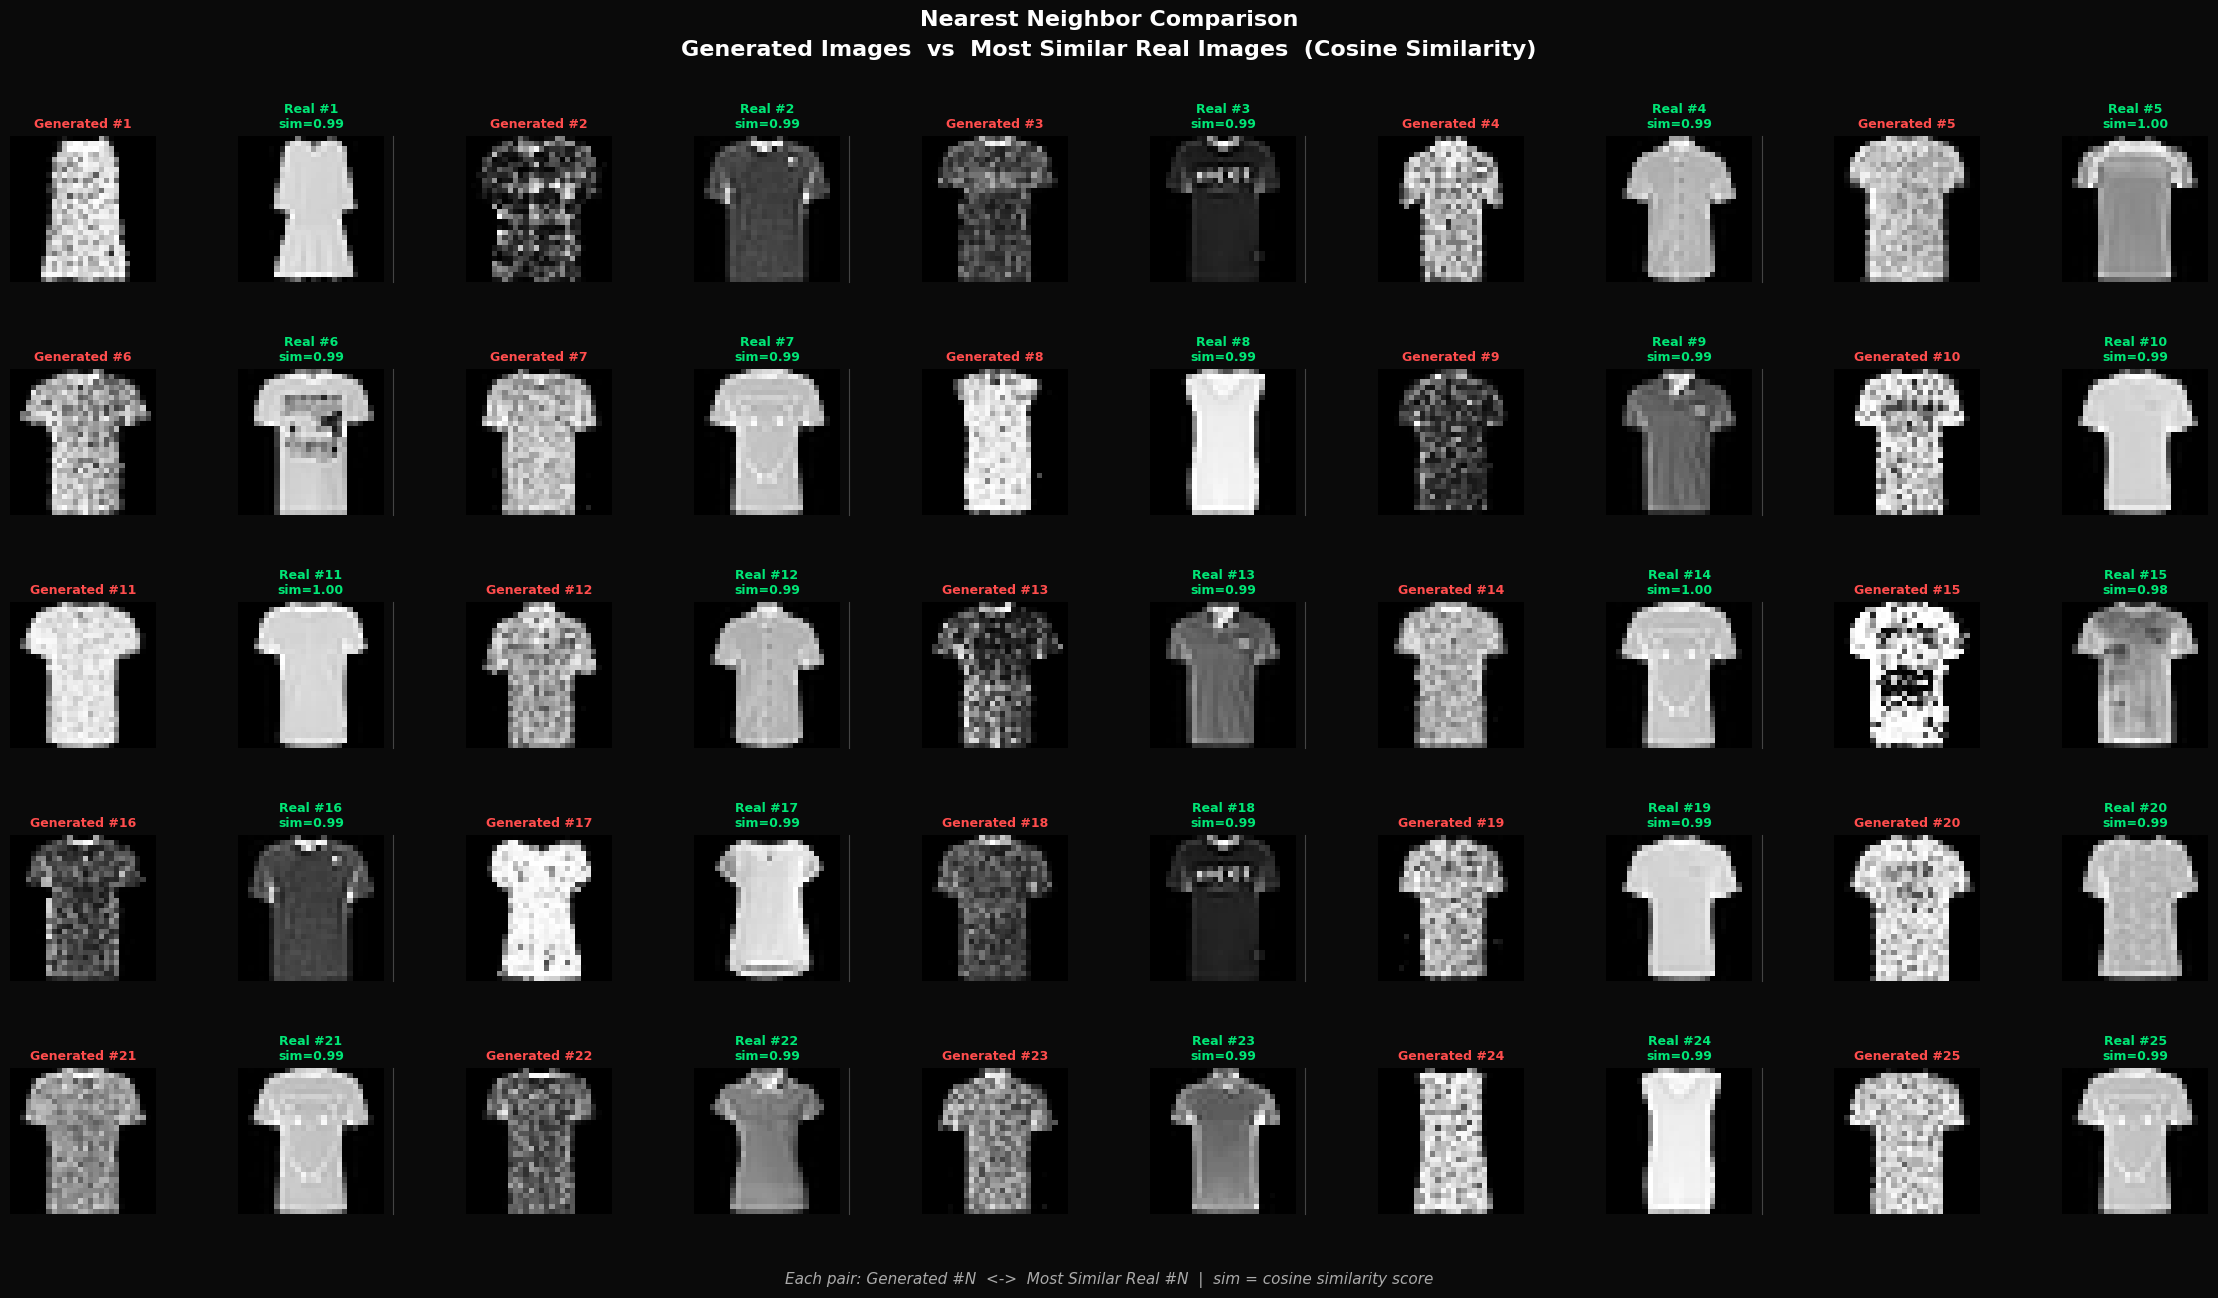

In [16]:
def get_real_images(dataset, n):
    imgs = []
    for batch, _ in dataset:
        imgs.append(batch.numpy())
        if sum(len(b) for b in imgs) >= n:
            break
    return np.concatenate(imgs, axis=0)[:n]

def denorm(imgs):
    return ((imgs + 1) / 2).clip(0, 1)

z         = tf.random.normal([25, LATENT_DIM])
fake_imgs = g_model([z, tf.zeros([25], dtype=tf.int32)], training=False).numpy()

real_imgs_sample = get_real_images(train_dataset, 500)

fake_flat  = denorm(fake_imgs).reshape(25, -1)
real_flat  = denorm(real_imgs_sample).reshape(500, -1)
sims       = cosine_similarity(fake_flat, real_flat)
nn_indices = sims.argmax(axis=1)
nn_real    = real_imgs_sample[nn_indices]
nn_scores  = sims.max(axis=1)

fig, axes = plt.subplots(5, 10, figsize=(24, 14), facecolor='#0a0a0a')
plt.subplots_adjust(hspace=0.6, wspace=0.12,
                    top=0.85, bottom=0.08,
                    left=0.03, right=0.97)

for i in range(25):
    row    = i // 5
    col    = (i % 5) * 2
    pair_id = i + 1

    fake = denorm(fake_imgs[i]).squeeze()
    real = denorm(nn_real[i]).squeeze()
    score = nn_scores[i]

    ax1 = axes[row, col]
    ax1.imshow(fake, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f'Generated #{pair_id}',
                  color='#ff4d4d', fontsize=9,
                  fontweight='bold', pad=6)

    ax2 = axes[row, col + 1]
    ax2.imshow(real, cmap='gray')
    ax2.axis('off')
    ax2.set_title(f'Real #{pair_id}\nsim={score:.2f}',
                  color='#00e676', fontsize=9,
                  fontweight='bold', pad=6)

    if (i % 5) != 4:
        fig.add_artist(
            plt.Line2D(
                [axes[row, col + 1].get_position().x1 + 0.004,
                 axes[row, col + 1].get_position().x1 + 0.004],
                [axes[row, col].get_position().y0,
                 axes[row, col].get_position().y1],
                transform=fig.transFigure,
                color='#444444', linewidth=0.8
            )
        )

plt.suptitle(
    'Nearest Neighbor Comparison\n'
    'Generated Images  vs  Most Similar Real Images  (Cosine Similarity)',
    color='white', fontsize=16, fontweight='bold',
    y=0.94, linespacing=1.6
)

fig.text(0.5, 0.03,
         'Each pair: Generated #N  <->  Most Similar Real #N  |  sim = cosine similarity score',
         ha='center', fontsize=11, color='#aaaaaa', style='italic')

plt.savefig('nearest_neighbor_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

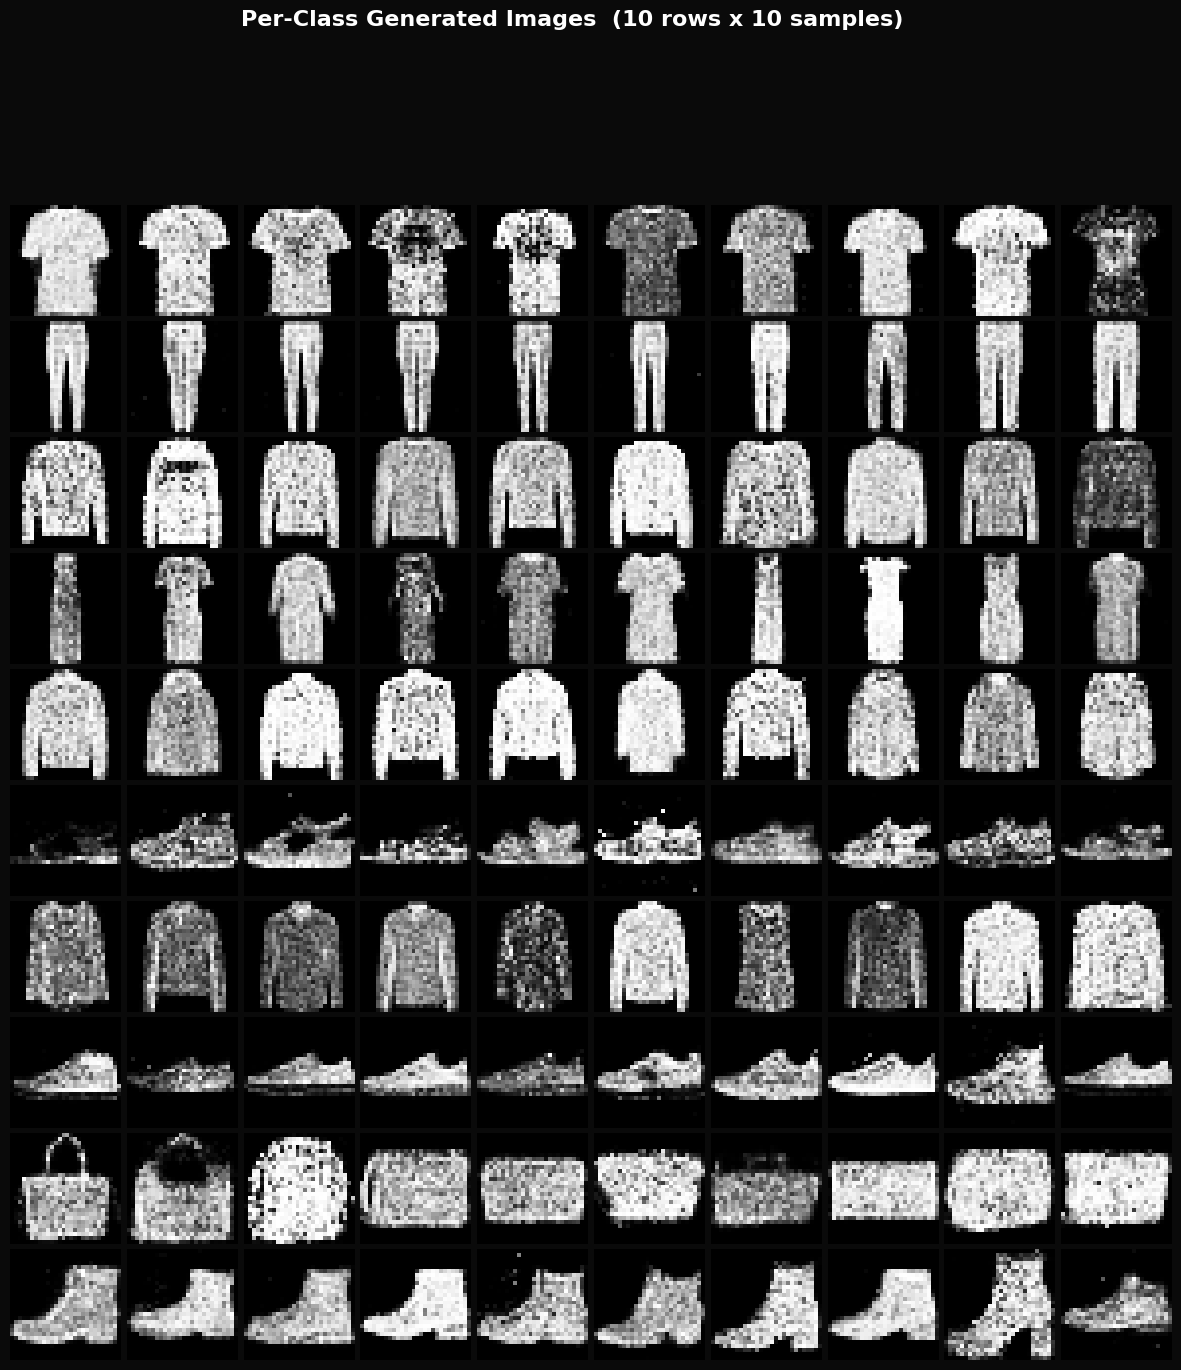

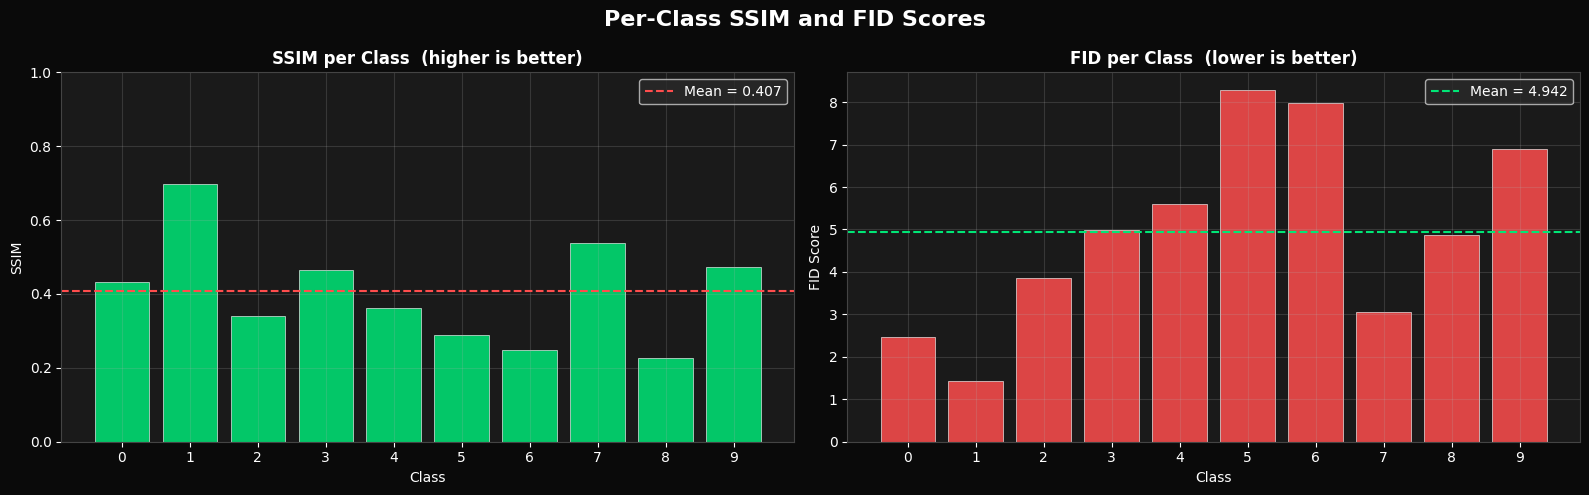

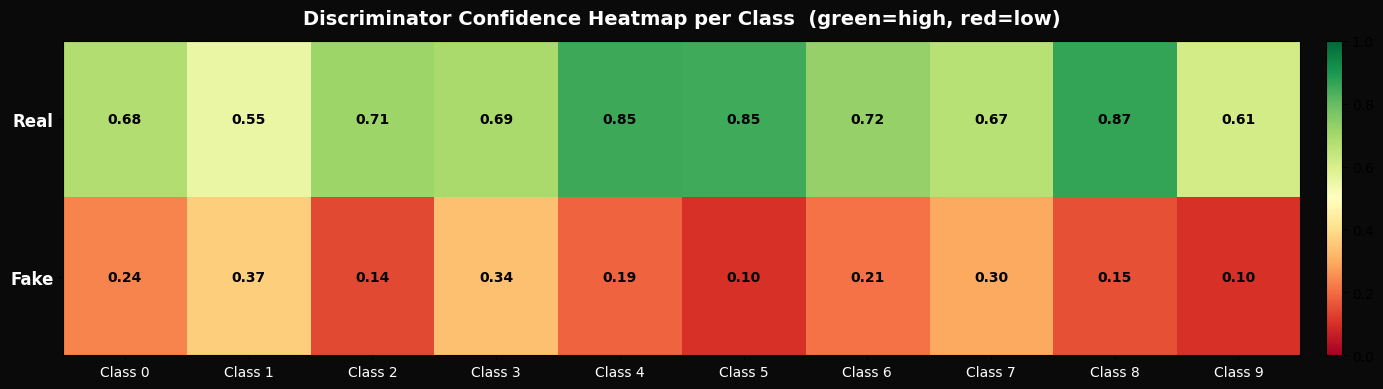

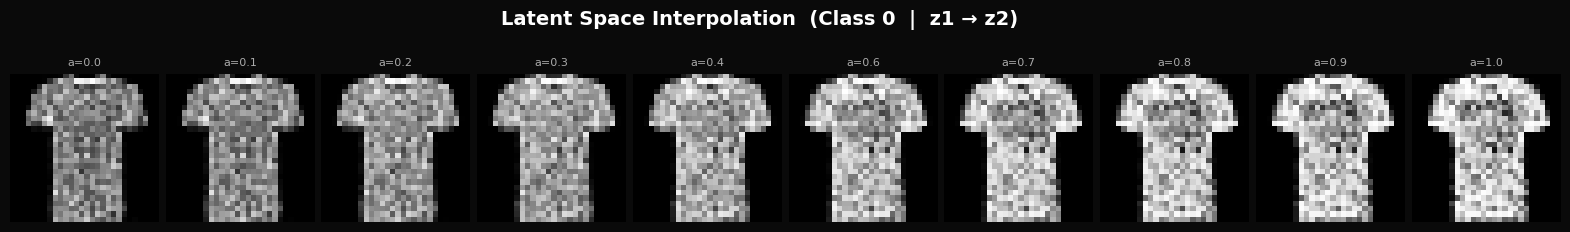

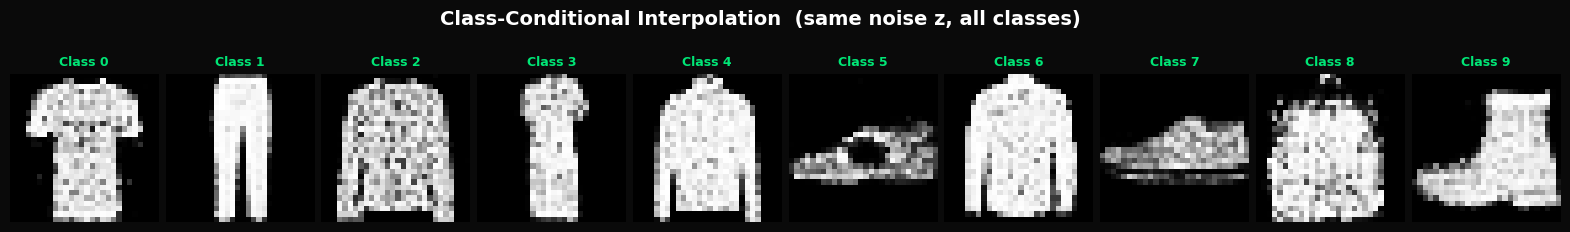

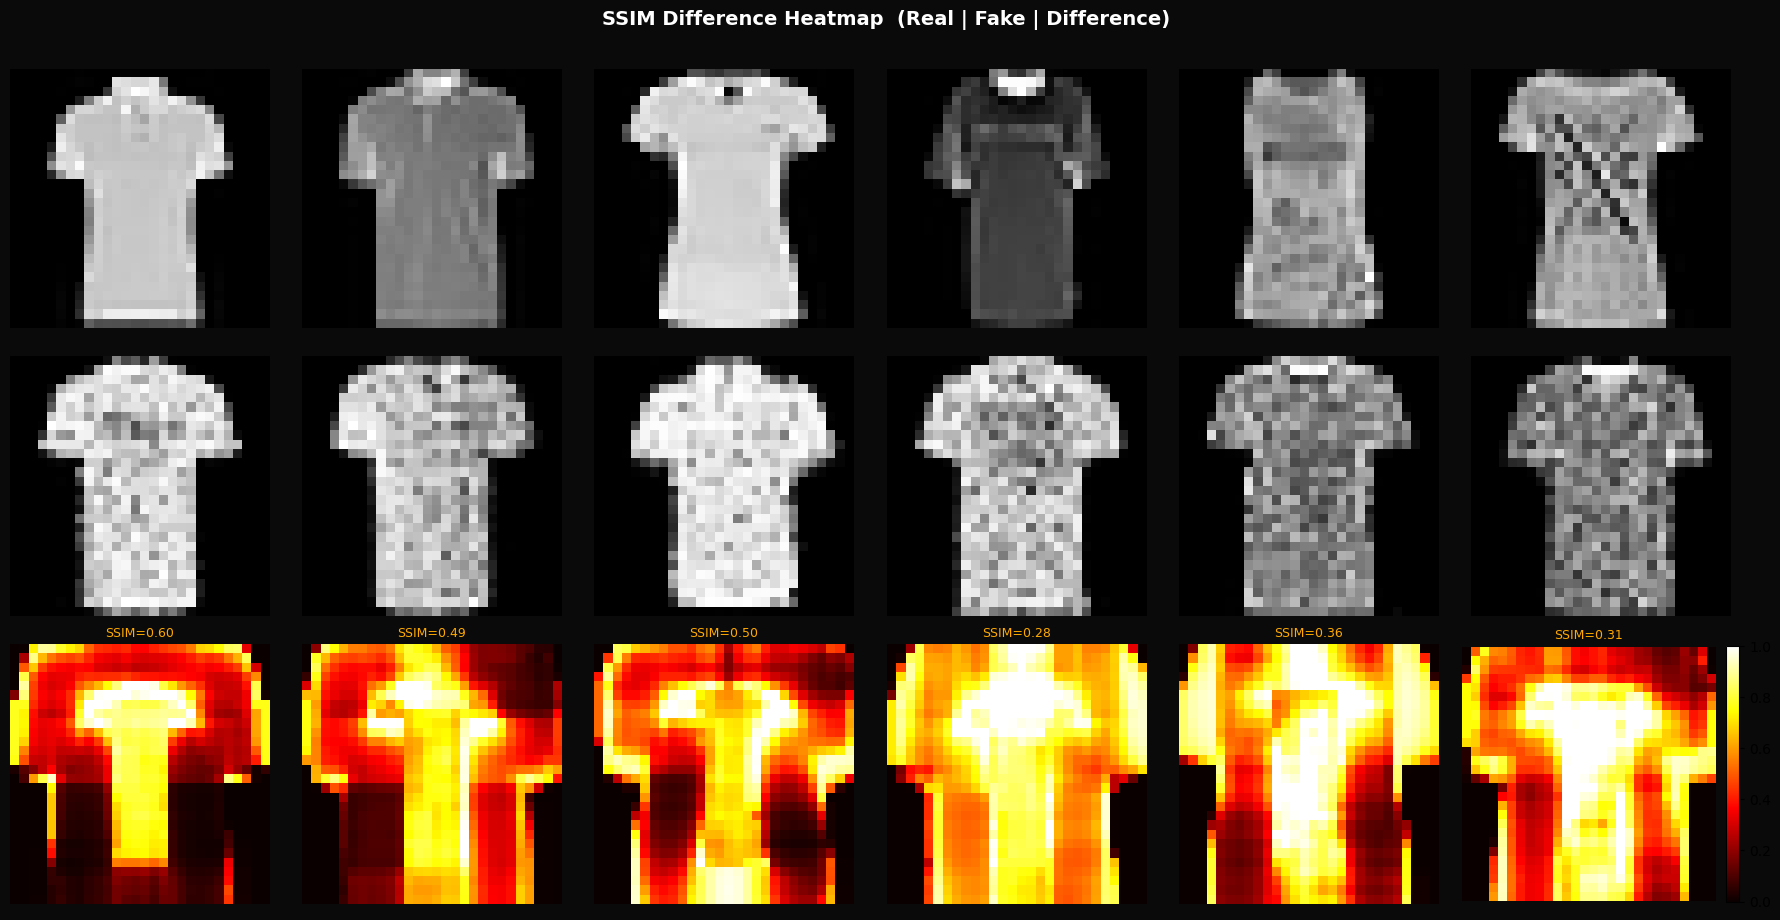

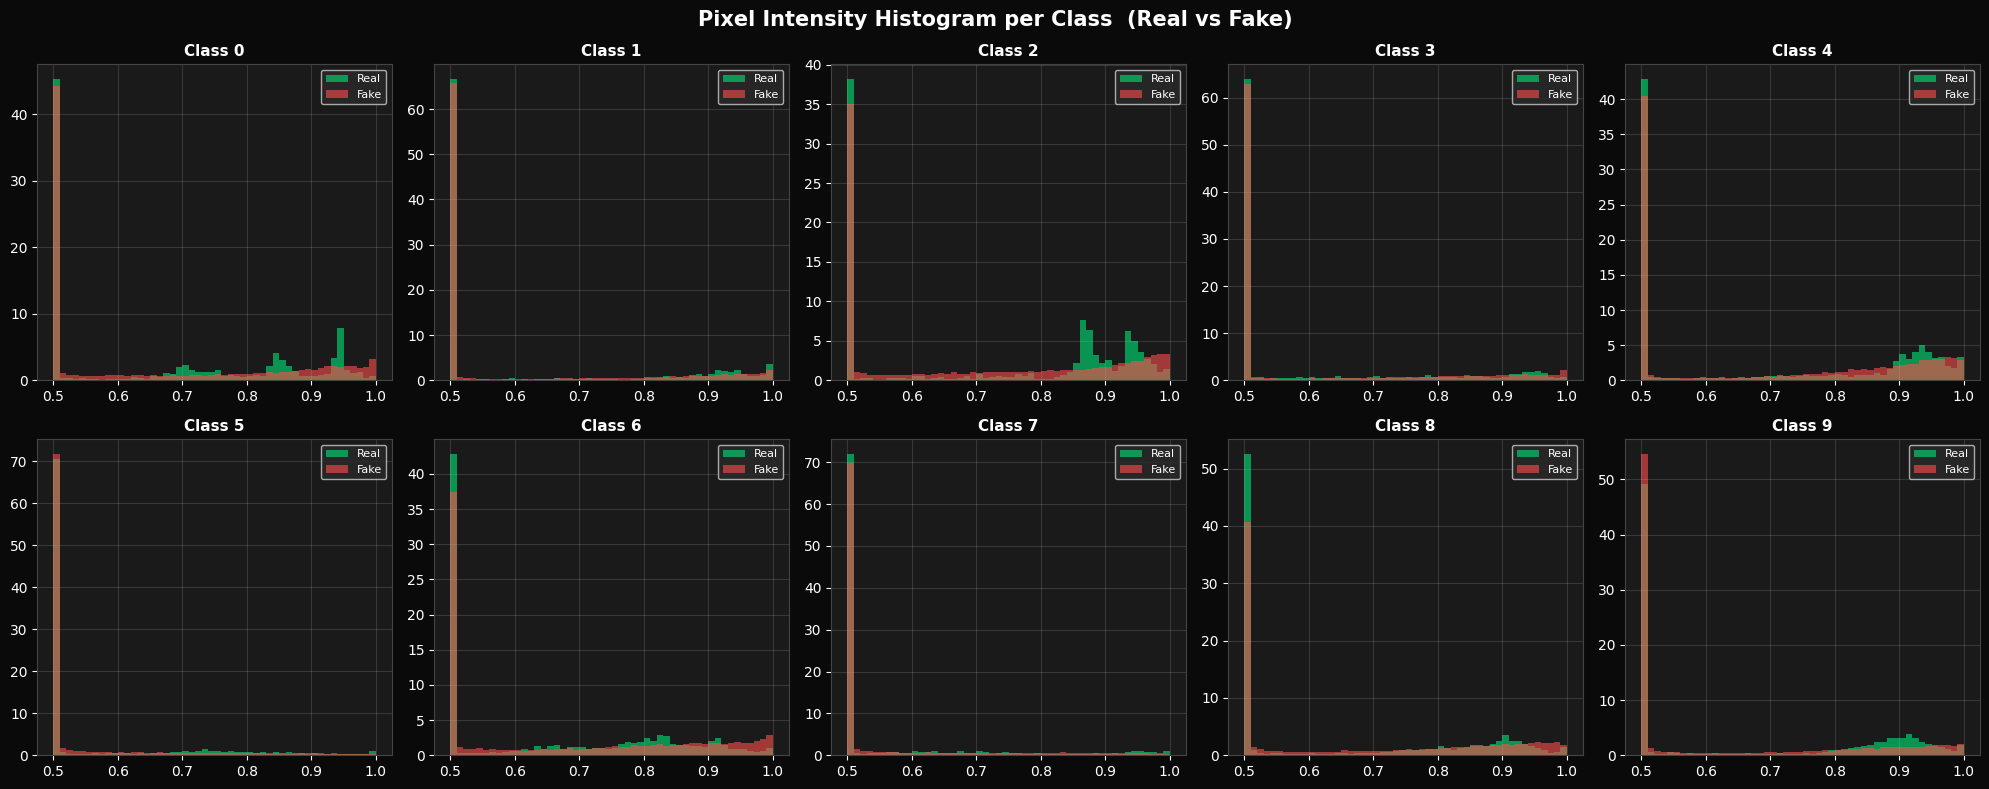

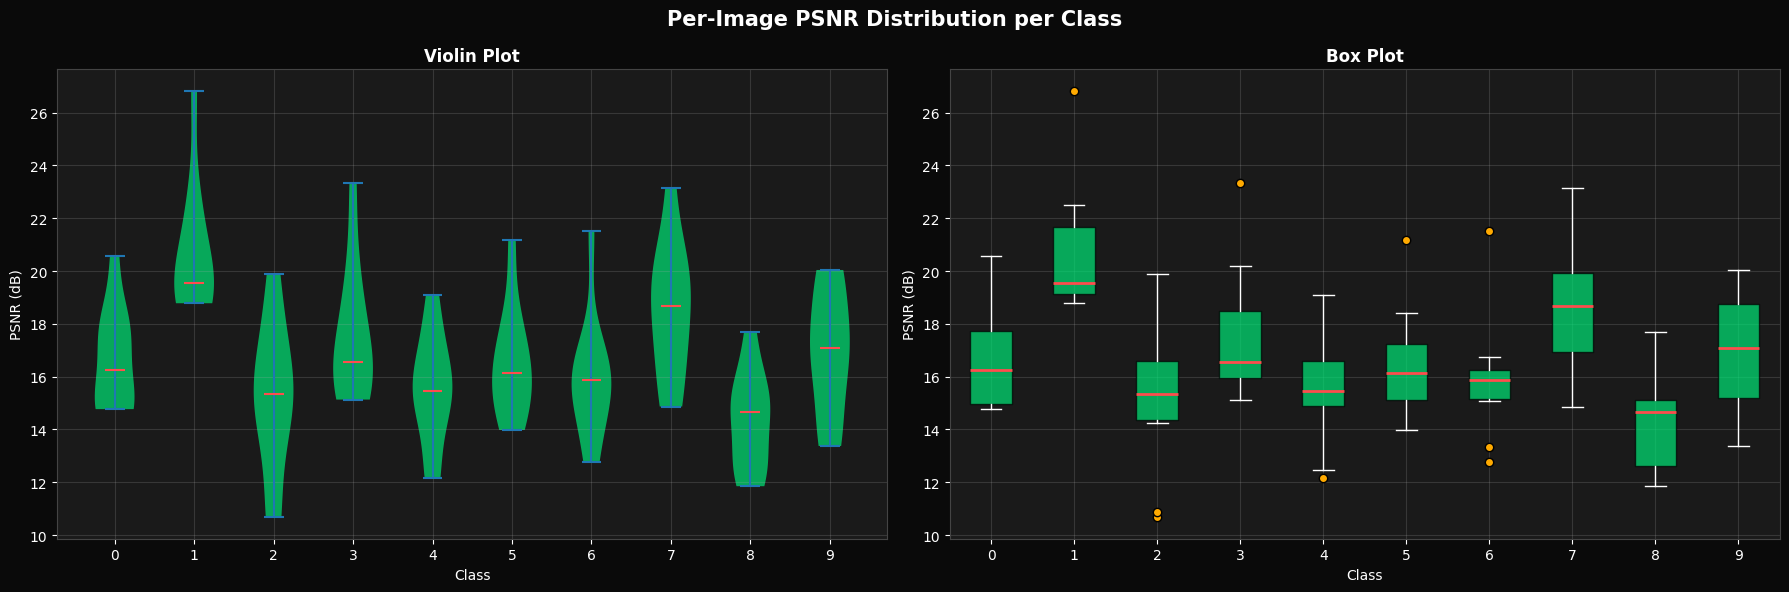

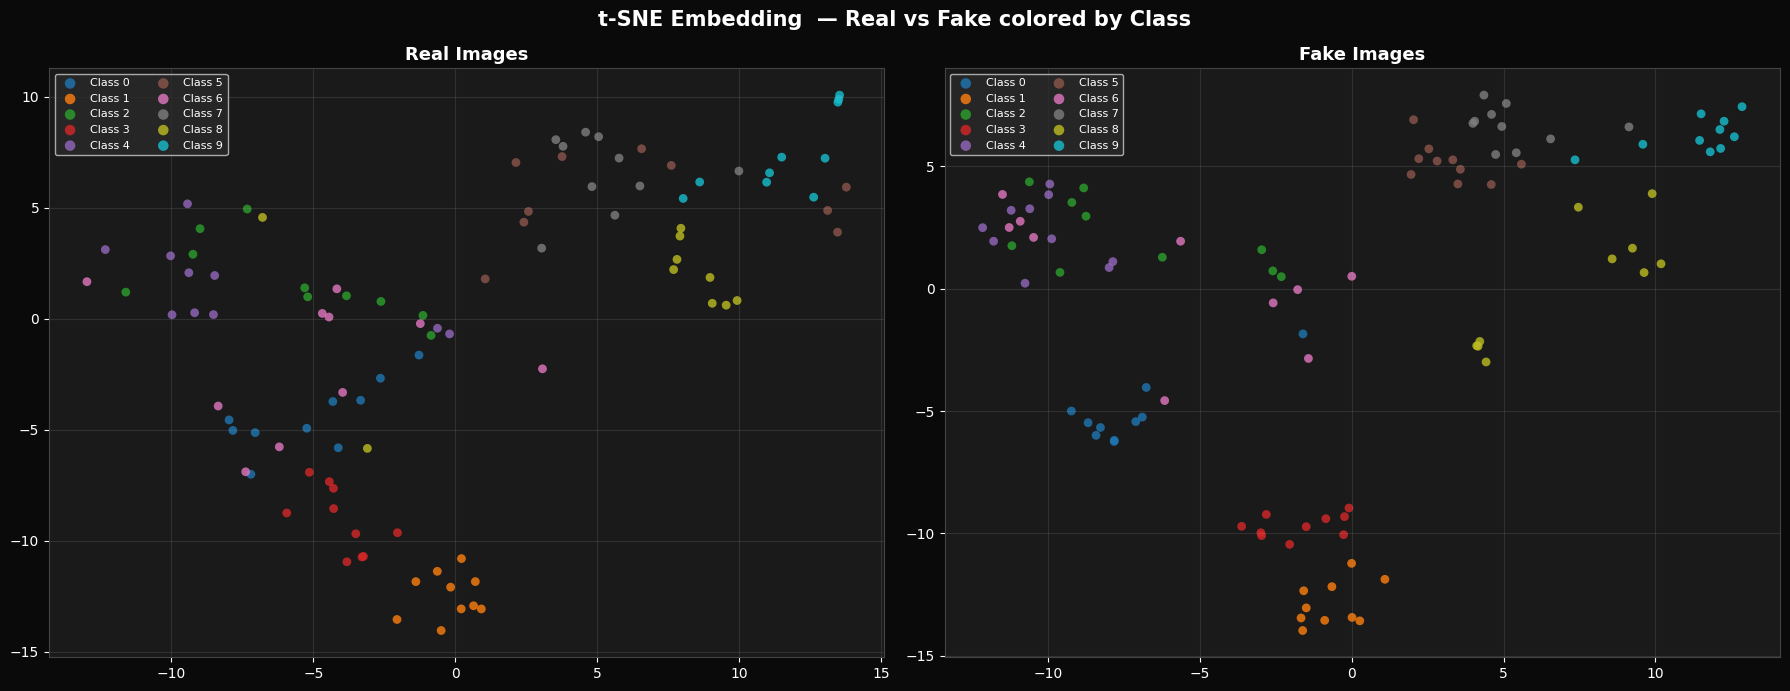

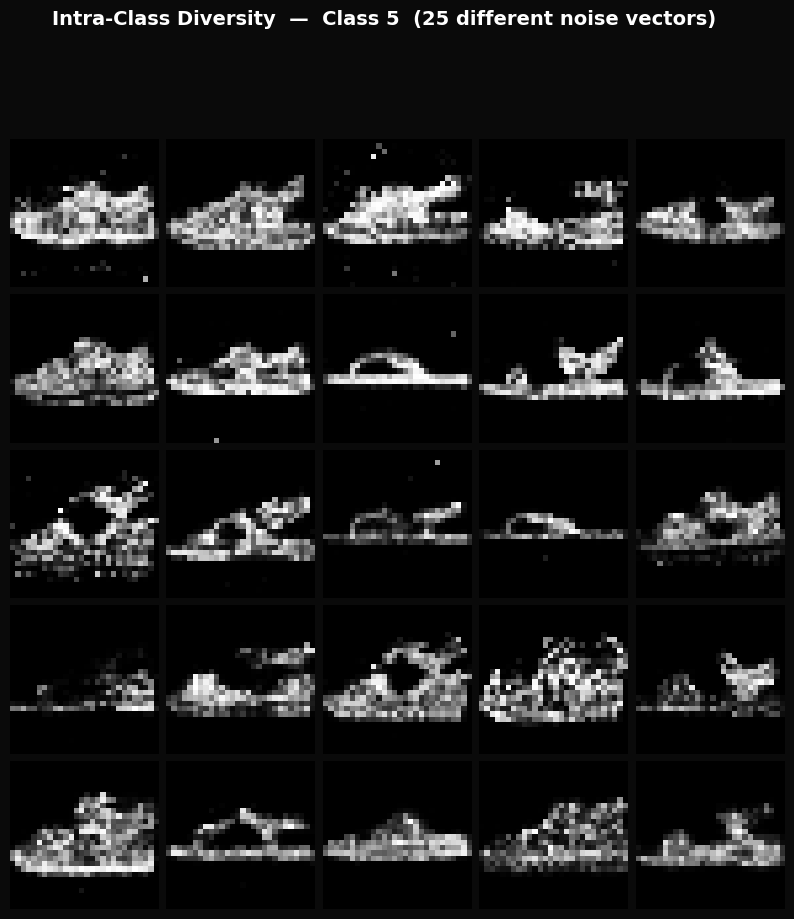

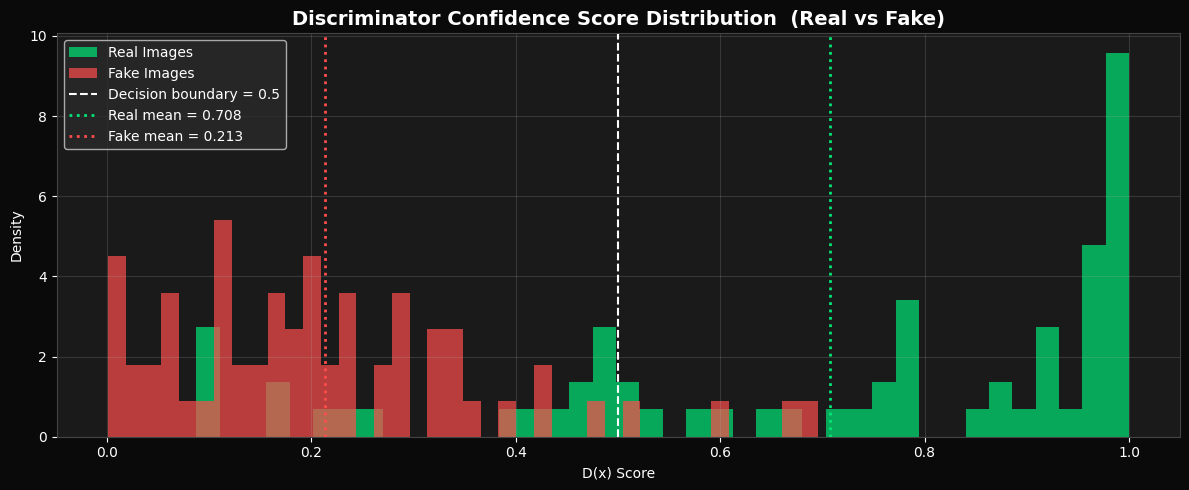

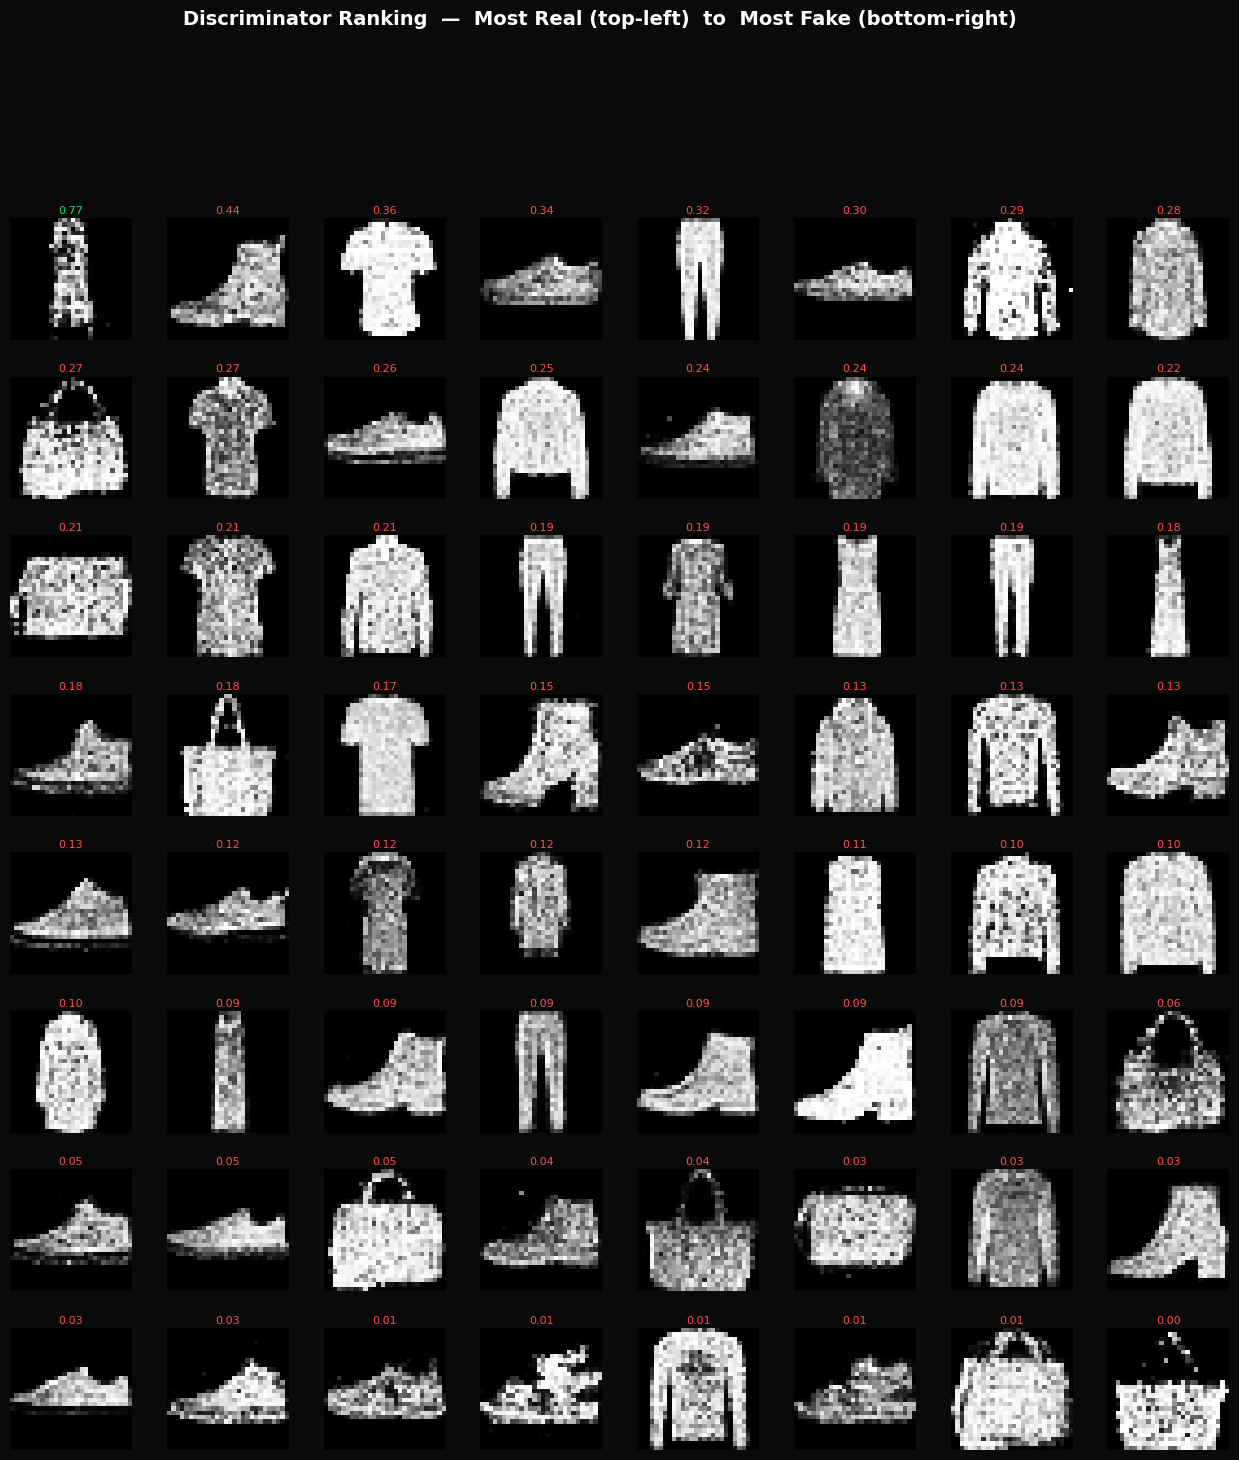

In [17]:
NUM_CLASSES = 10
SAMPLES_PER_CLASS = 10

def denorm(imgs):
    return ((imgs + 1) / 2).clip(0, 1)

def get_real_by_class(dataset, num_classes, samples_per_class):
    buckets = {i: [] for i in range(num_classes)}
    for imgs, labels in dataset:
        for img, lbl in zip(imgs.numpy(), labels.numpy()):
            l = int(lbl)
            if len(buckets[l]) < samples_per_class:
                buckets[l].append(img)
        if all(len(v) >= samples_per_class for v in buckets.values()):
            break
    return buckets

real_buckets = get_real_by_class(train_dataset, NUM_CLASSES, SAMPLES_PER_CLASS)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. PER-CLASS GRID — 10 rows x 10 samples
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS,
                         figsize=(SAMPLES_PER_CLASS * 1.5, NUM_CLASSES * 1.5),
                         facecolor='#0a0a0a')
fig.suptitle('Per-Class Generated Images  (10 rows x 10 samples)',
             fontsize=16, fontweight='bold', color='white', y=1.01)

for cls in range(NUM_CLASSES):
    z      = tf.random.normal([SAMPLES_PER_CLASS, LATENT_DIM])
    labels = tf.fill([SAMPLES_PER_CLASS], cls)
    imgs   = denorm(g_model([z, labels], training=False).numpy())
    for j in range(SAMPLES_PER_CLASS):
        ax = axes[cls, j]
        ax.imshow(imgs[j].squeeze(), cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'Class {cls}', color='#00e676',
                          fontsize=10, fontweight='bold', rotation=0,
                          labelpad=40, va='center')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('per_class_grid.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PER-CLASS SSIM / FID BAR CHART
# ═══════════════════════════════════════════════════════════════════════════════
def compute_fid_small(real_f, fake_f):
    mu1, mu2   = np.mean(real_f, axis=0), np.mean(fake_f, axis=0)
    sigma1     = np.cov(real_f, rowvar=False) if len(real_f) > 1 else np.eye(real_f.shape[1])
    sigma2     = np.cov(fake_f, rowvar=False) if len(fake_f) > 1 else np.eye(fake_f.shape[1])
    diff       = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

class_ssim, class_fid = [], []
for cls in range(NUM_CLASSES):
    real_imgs = np.array(real_buckets[cls])
    z         = tf.random.normal([SAMPLES_PER_CLASS, LATENT_DIM])
    labels    = tf.fill([SAMPLES_PER_CLASS], cls)
    fake_imgs = denorm(g_model([z, labels], training=False).numpy())
    real_d    = denorm(real_imgs)

    s_scores = [ssim(real_d[i].squeeze(), fake_imgs[i].squeeze(), data_range=1.0)
                for i in range(SAMPLES_PER_CLASS)]
    class_ssim.append(np.mean(s_scores))

    pca = PCA(n_components=min(8, SAMPLES_PER_CLASS - 1))
    r_f = pca.fit_transform(real_d.reshape(SAMPLES_PER_CLASS, -1))
    f_f = pca.transform(fake_imgs.reshape(SAMPLES_PER_CLASS, -1))
    class_fid.append(compute_fid_small(r_f, f_f))

x      = np.arange(NUM_CLASSES)
width  = 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0a0a0a')
fig.suptitle('Per-Class SSIM and FID Scores',
             fontsize=16, fontweight='bold', color='white')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

ax1.bar(x, class_ssim, color='#00e676', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_title('SSIM per Class  (higher is better)', fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('SSIM')
ax1.set_xticks(x)
ax1.set_ylim(0, 1)
ax1.axhline(np.mean(class_ssim), color='#ff4d4d', linestyle='--', linewidth=1.5,
            label=f'Mean = {np.mean(class_ssim):.3f}')
ax1.legend(facecolor='#2a2a2a', labelcolor='white')
ax1.grid(True, alpha=0.2)

ax2.bar(x, class_fid, color='#ff4d4d', alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.set_title('FID per Class  (lower is better)', fontweight='bold')
ax2.set_xlabel('Class')
ax2.set_ylabel('FID Score')
ax2.set_xticks(x)
ax2.axhline(np.mean(class_fid), color='#00e676', linestyle='--', linewidth=1.5,
            label=f'Mean = {np.mean(class_fid):.3f}')
ax2.legend(facecolor='#2a2a2a', labelcolor='white')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('per_class_ssim_fid.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 3. DISCRIMINATOR CONFIDENCE HEATMAP PER CLASS
# ═══════════════════════════════════════════════════════════════════════════════
real_conf = np.zeros(NUM_CLASSES)
fake_conf = np.zeros(NUM_CLASSES)

for cls in range(NUM_CLASSES):
    real_imgs  = tf.convert_to_tensor(np.array(real_buckets[cls]), dtype=tf.float32)
    cls_labels = tf.fill([SAMPLES_PER_CLASS], cls)
    z          = tf.random.normal([SAMPLES_PER_CLASS, LATENT_DIM])
    fake_imgs  = g_model([z, cls_labels], training=False)
    real_conf[cls] = np.mean(d_model([real_imgs, cls_labels], training=False).numpy())
    fake_conf[cls] = np.mean(d_model([fake_imgs, cls_labels], training=False).numpy())

heatmap_data = np.stack([real_conf, fake_conf], axis=0)

fig, ax = plt.subplots(figsize=(14, 4), facecolor='#0a0a0a')
ax.set_facecolor('#1a1a1a')
im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Real', 'Fake'], color='white', fontsize=12, fontweight='bold')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([f'Class {i}' for i in range(NUM_CLASSES)], color='white', fontsize=10)
ax.set_title('Discriminator Confidence Heatmap per Class  (green=high, red=low)',
             color='white', fontsize=14, fontweight='bold', pad=12)

for i in range(2):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{heatmap_data[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.savefig('disc_confidence_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. LATENT SPACE INTERPOLATION
# ═══════════════════════════════════════════════════════════════════════════════
STEPS     = 10
fix_class = 0
z1 = tf.random.normal([1, LATENT_DIM])
z2 = tf.random.normal([1, LATENT_DIM])
alphas     = np.linspace(0, 1, STEPS)
interp_z   = tf.concat([z1 * (1 - a) + z2 * a for a in alphas], axis=0)
interp_lbl = tf.fill([STEPS], fix_class)
interp_imgs = denorm(g_model([interp_z, interp_lbl], training=False).numpy())

fig, axes = plt.subplots(1, STEPS, figsize=(STEPS * 2, 2.5), facecolor='#0a0a0a')
fig.suptitle(f'Latent Space Interpolation  (Class {fix_class}  |  z1 → z2)',
             fontsize=14, fontweight='bold', color='white', y=1.05)

for i, ax in enumerate(axes):
    ax.imshow(interp_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'a={alphas[i]:.1f}', color='#aaaaaa', fontsize=8)

plt.subplots_adjust(wspace=0.05)
plt.savefig('latent_interpolation.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. CLASS-CONDITIONAL INTERPOLATION — same noise, walk through all classes
# ═══════════════════════════════════════════════════════════════════════════════
fix_z      = tf.random.normal([1, LATENT_DIM])
fix_z_rep  = tf.repeat(fix_z, NUM_CLASSES, axis=0)
all_labels = tf.range(NUM_CLASSES)
cond_imgs  = denorm(g_model([fix_z_rep, all_labels], training=False).numpy())

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 2, 2.5),
                         facecolor='#0a0a0a')
fig.suptitle('Class-Conditional Interpolation  (same noise z, all classes)',
             fontsize=14, fontweight='bold', color='white', y=1.05)

for cls, ax in enumerate(axes):
    ax.imshow(cond_imgs[cls].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Class {cls}', color='#00e676', fontsize=9, fontweight='bold')

plt.subplots_adjust(wspace=0.05)
plt.savefig('class_conditional_interpolation.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. SSIM HEATMAP OVERLAY — region-level difference map
# ═══════════════════════════════════════════════════════════════════════════════
N_PAIRS = 6
real_sample_imgs = np.array(real_buckets[0])[:N_PAIRS]
z          = tf.random.normal([N_PAIRS, LATENT_DIM])
lbl        = tf.fill([N_PAIRS], 0)
fake_sample = denorm(g_model([z, lbl], training=False).numpy())
real_sample_d = denorm(real_sample_imgs)

fig, axes = plt.subplots(3, N_PAIRS, figsize=(N_PAIRS * 3, 9), facecolor='#0a0a0a')
fig.suptitle('SSIM Difference Heatmap  (Real | Fake | Difference)',
             fontsize=14, fontweight='bold', color='white', y=1.01)
row_labels = ['Real', 'Fake', 'Diff Map']
row_colors = ['#00e676', '#ff4d4d', '#ffaa00']

for i in range(N_PAIRS):
    r = real_sample_d[i].squeeze()
    f = fake_sample[i].squeeze()
    score, diff = ssim(r, f, data_range=1.0, full=True)
    diff_map    = 1 - diff

    axes[0, i].imshow(r, cmap='gray')
    axes[1, i].imshow(f, cmap='gray')
    im = axes[2, i].imshow(diff_map, cmap='hot', vmin=0, vmax=1)
    axes[2, i].set_title(f'SSIM={score:.2f}', color='#ffaa00', fontsize=9)

    for row in range(3):
        axes[row, i].axis('off')

for row, (lbl_txt, col) in enumerate(zip(row_labels, row_colors)):
    axes[row, 0].set_ylabel(lbl_txt, color=col, fontsize=11,
                            fontweight='bold', rotation=0,
                            labelpad=50, va='center')

plt.colorbar(im, ax=axes[2, -1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('ssim_heatmap_overlay.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. PIXEL INTENSITY HISTOGRAM — real vs fake overlay
# ═══════════════════════════════════════════════════════════════════════════════

real_hist_imgs, real_hist_labels = next(iter(train_dataset))
N_HIST = len(real_hist_imgs)                  # match exactly to batch size

real_hist_imgs = denorm(real_hist_imgs.numpy())
real_hist_labels_np = real_hist_labels.numpy()

z_hist         = tf.random.normal([N_HIST, LATENT_DIM])
fake_hist_imgs = denorm(g_model([z_hist, real_hist_labels], training=False).numpy())

fig, axes = plt.subplots(2, 5, figsize=(20, 8), facecolor='#0a0a0a')
fig.suptitle('Pixel Intensity Histogram per Class  (Real vs Fake)',
             fontsize=15, fontweight='bold', color='white')

for cls in range(NUM_CLASSES):
    ax = axes[cls // 5, cls % 5]
    ax.set_facecolor('#1a1a1a')

    r_px = real_hist_imgs[real_hist_labels_np == cls].flatten()
    z_c  = tf.random.normal([30, LATENT_DIM])
    l_c  = tf.fill([30], cls)
    f_px = denorm(g_model([z_c, l_c], training=False).numpy()).flatten()

    ax.hist(r_px, bins=50, color='#00e676', alpha=0.6, density=True, label='Real')
    ax.hist(f_px, bins=50, color='#ff4d4d', alpha=0.6, density=True, label='Fake')
    ax.set_title(f'Class {cls}', color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='white')
    ax.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=8)
    ax.grid(True, alpha=0.2)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

plt.tight_layout()
plt.savefig('pixel_histogram.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 8. PER-IMAGE PSNR VIOLIN / BOX PLOT
# ═══════════════════════════════════════════════════════════════════════════════
def psnr(r, f):
    mse = np.mean((r - f) ** 2)
    return 20 * np.log10(1.0 / (np.sqrt(mse) + 1e-8))

psnr_per_class = []
for cls in range(NUM_CLASSES):
    real_c = denorm(np.array(real_buckets[cls]))
    z_c    = tf.random.normal([SAMPLES_PER_CLASS, LATENT_DIM])
    l_c    = tf.fill([SAMPLES_PER_CLASS], cls)
    fake_c = denorm(g_model([z_c, l_c], training=False).numpy())
    psnr_per_class.append([psnr(real_c[i], fake_c[i]) for i in range(SAMPLES_PER_CLASS)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), facecolor='#0a0a0a')
fig.suptitle('Per-Image PSNR Distribution per Class',
             fontsize=15, fontweight='bold', color='white')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

vp = ax1.violinplot(psnr_per_class, positions=range(NUM_CLASSES), showmedians=True)
for body in vp['bodies']:
    body.set_facecolor('#00e676')
    body.set_alpha(0.7)
vp['cmedians'].set_color('#ff4d4d')
ax1.set_title('Violin Plot', fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('PSNR (dB)')
ax1.set_xticks(range(NUM_CLASSES))
ax1.grid(True, alpha=0.2)

bp = ax2.boxplot(psnr_per_class, positions=range(NUM_CLASSES),
                 patch_artist=True,
                 boxprops=dict(facecolor='#00e676', alpha=0.7),
                 medianprops=dict(color='#ff4d4d', linewidth=2),
                 whiskerprops=dict(color='white'),
                 capprops=dict(color='white'),
                 flierprops=dict(markerfacecolor='#ffaa00', marker='o'))
ax2.set_title('Box Plot', fontweight='bold')
ax2.set_xlabel('Class')
ax2.set_ylabel('PSNR (dB)')
ax2.set_xticks(range(NUM_CLASSES))
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('psnr_violin_box.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 9. t-SNE SCATTER — real vs fake colored by class
# ═══════════════════════════════════════════════════════════════════════════════
N_TSNE   = 50
real_tsne_imgs, real_tsne_labels = [], []
for cls in range(NUM_CLASSES):
    real_tsne_imgs.append(denorm(np.array(real_buckets[cls])))
    real_tsne_labels.extend([cls] * SAMPLES_PER_CLASS)
real_tsne_imgs = np.concatenate(real_tsne_imgs, axis=0)

fake_tsne_imgs, fake_tsne_labels = [], []
for cls in range(NUM_CLASSES):
    z_t = tf.random.normal([SAMPLES_PER_CLASS, LATENT_DIM])
    l_t = tf.fill([SAMPLES_PER_CLASS], cls)
    fake_tsne_imgs.append(denorm(g_model([z_t, l_t], training=False).numpy()))
    fake_tsne_labels.extend([cls] * SAMPLES_PER_CLASS)
fake_tsne_imgs = np.concatenate(fake_tsne_imgs, axis=0)

all_imgs   = np.concatenate([real_tsne_imgs, fake_tsne_imgs], axis=0).reshape(len(real_tsne_imgs) + len(fake_tsne_imgs), -1)
all_labels = real_tsne_labels + fake_tsne_labels
all_types  = ['Real'] * len(real_tsne_imgs) + ['Fake'] * len(fake_tsne_imgs)

tsne      = TSNE(n_components=2, random_state=42, perplexity=30)
embedding = tsne.fit_transform(all_imgs)

cmap   = plt.cm.get_cmap('tab10', NUM_CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0a0a0a')
fig.suptitle('t-SNE Embedding  — Real vs Fake colored by Class',
             fontsize=15, fontweight='bold', color='white')

titles = ['Real Images', 'Fake Images']
masks  = [np.array(all_types) == 'Real', np.array(all_types) == 'Fake']

for ax, title, mask in zip(axes, titles, masks):
    ax.set_facecolor('#1a1a1a')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    lbls = np.array(all_labels)[mask]
    emb  = embedding[mask]
    for cls in range(NUM_CLASSES):
        idx = lbls == cls
        ax.scatter(emb[idx, 0], emb[idx, 1], c=[cmap(cls)],
                   label=f'Class {cls}', s=40, alpha=0.8, edgecolors='none')
    ax.legend(facecolor='#2a2a2a', labelcolor='white',
              fontsize=8, ncol=2, markerscale=1.2)
    ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('tsne_scatter.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 10. INTRA-CLASS DIVERSITY GRID — same class generated 25 times
# ═══════════════════════════════════════════════════════════════════════════════
DIVERSITY_CLASS = 5
z_div   = tf.random.normal([25, LATENT_DIM])
lbl_div = tf.fill([25], DIVERSITY_CLASS)
div_imgs = denorm(g_model([z_div, lbl_div], training=False).numpy())

fig, axes = plt.subplots(5, 5, figsize=(10, 10), facecolor='#0a0a0a')
fig.suptitle(f'Intra-Class Diversity  —  Class {DIVERSITY_CLASS}  (25 different noise vectors)',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(div_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig('intra_class_diversity.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 11. DISCRIMINATOR CONFIDENCE SCORE HISTOGRAM
# ═══════════════════════════════════════════════════════════════════════════════
N_CONF = 500
real_conf_imgs, real_conf_labels = next(iter(train_dataset))
real_conf_imgs   = real_conf_imgs[:N_CONF]
real_conf_labels = real_conf_labels[:N_CONF]
z_conf    = tf.random.normal([len(real_conf_imgs), LATENT_DIM])
fake_conf_imgs = g_model([z_conf, real_conf_labels], training=False)

real_scores = d_model([real_conf_imgs, real_conf_labels], training=False).numpy().flatten()
fake_scores = d_model([fake_conf_imgs, real_conf_labels], training=False).numpy().flatten()

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0a0a0a')
ax.set_facecolor('#1a1a1a')
ax.hist(real_scores, bins=40, color='#00e676', alpha=0.7, density=True, label='Real Images')
ax.hist(fake_scores, bins=40, color='#ff4d4d', alpha=0.7, density=True, label='Fake Images')
ax.axvline(0.5, color='white', linestyle='--', linewidth=1.5, label='Decision boundary = 0.5')
ax.axvline(np.mean(real_scores), color='#00e676', linestyle=':',
           linewidth=2, label=f'Real mean = {np.mean(real_scores):.3f}')
ax.axvline(np.mean(fake_scores), color='#ff4d4d', linestyle=':',
           linewidth=2, label=f'Fake mean = {np.mean(fake_scores):.3f}')
ax.set_title('Discriminator Confidence Score Distribution  (Real vs Fake)',
             color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('D(x) Score', color='white')
ax.set_ylabel('Density',    color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#2a2a2a', labelcolor='white')
ax.grid(True, alpha=0.2)
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')

plt.tight_layout()
plt.savefig('disc_confidence_histogram.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 12. DISCRIMINATOR RANKING — sorted from most-real to most-fake
# ═══════════════════════════════════════════════════════════════════════════════
N_RANK = 64
z_rank    = tf.random.normal([N_RANK, LATENT_DIM])
lbl_rank  = tf.random.uniform([N_RANK], 0, NUM_CLASSES, dtype=tf.int32)
fake_rank = g_model([z_rank, lbl_rank], training=False)
rank_scores = d_model([fake_rank, lbl_rank], training=False).numpy().flatten()
rank_imgs   = denorm(fake_rank.numpy())

sorted_idx  = np.argsort(rank_scores)[::-1]   # high → low
sorted_imgs = rank_imgs[sorted_idx]
sorted_scr  = rank_scores[sorted_idx]

fig, axes = plt.subplots(8, 8, figsize=(16, 16), facecolor='#0a0a0a')
fig.suptitle('Discriminator Ranking  —  Most Real (top-left)  to  Most Fake (bottom-right)',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(sorted_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
    score = sorted_scr[i]
    color = '#00e676' if score >= 0.5 else '#ff4d4d'
    ax.set_title(f'{score:.2f}', color=color, fontsize=8, pad=3)

plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.savefig('disc_ranking.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


In [18]:
os.makedirs('/kaggle/working/gif_frames', exist_ok=True)

FRAMES     = 50
GIF_ROWS   = 5
GIF_COLS   = 5
N_IMGS     = GIF_ROWS * GIF_COLS

fixed_noise  = tf.random.normal([N_IMGS, LATENT_DIM])
fixed_labels = tf.constant([i % NUM_CLASSES for i in range(N_IMGS)])

z_start = tf.random.normal([N_IMGS, LATENT_DIM]) * 2.0
z_end   = fixed_noise

frame_paths = []
for f in range(FRAMES):
    alpha  = f / (FRAMES - 1)
    z_interp = z_start * (1 - alpha) + z_end * alpha

    imgs = denorm(g_model([z_interp, fixed_labels], training=False).numpy())

    fig, axes = plt.subplots(GIF_ROWS, GIF_COLS,
                             figsize=(GIF_COLS * 1.5, GIF_ROWS * 1.5),
                             facecolor='#0a0a0a')
    fig.suptitle(f'cGAN Generation  —  Frame {f + 1}/{FRAMES}',
                 fontsize=13, fontweight='bold', color='white', y=1.01)

    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
        ax.set_title(f'cls {int(fixed_labels[i])}',
                     color='#00e676', fontsize=7, pad=2)

    plt.subplots_adjust(wspace=0.05, hspace=0.15)
    path = f'/kaggle/working/gif_frames/frame_{f:03d}.png'
    plt.savefig(path, dpi=80, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    frame_paths.append(path)

In [19]:
gif_path = '/kaggle/working/cgan_generation.gif'
with imageio.get_writer(gif_path, mode='I', duration=0.1, loop=0) as writer:
    for path in frame_paths:
        writer.append_data(imageio.imread(path))
    for _ in range(10):
        writer.append_data(imageio.imread(frame_paths[-1]))

print(f'GIF saved: {gif_path}')

GIF saved: /kaggle/working/cgan_generation.gif


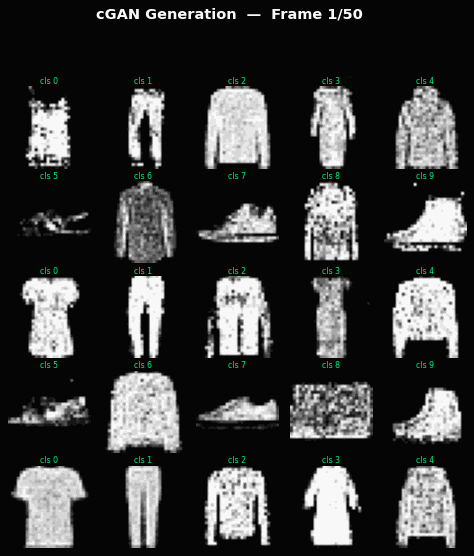

In [20]:
display(IPImage(filename=gif_path))